# `fire_los_recovery` — 6. The GP floor: the same measurement, in closed form

Notebooks 01–05 built, calibrated, and visualized the **PINN** pipeline. This
notebook answers the same question — *what do 50 noisy LOS accelerations plus
the Sun anchor say about the Galaxy's field?* — with **no neural network and
no training**: a Gaussian-process (equivalently, Wiener-filter) posterior,
computed exactly with ~50×50 linear algebra. It exists for three reasons:

1. **The control experiment.** For a linear-Gaussian model — smooth prior on
   the potential, observations *linear* in it, Gaussian noise — the GP
   posterior is the exact Bayesian answer. It is the *information floor* the
   PINN must be judged against: matching it means the network machinery added
   nothing; beating it means the gain is attributable to exactly what a
   Gaussian cannot encode (the ρ ≥ 0 inequality, non-Gaussian FIRE texture).
2. **Honest error bars.** The posterior comes with a covariance: per-point σ
   for **a**, Φ, and ρ, which we *test* against the FIRE truth (fig 8) instead
   of asserting.
3. **Experiment design.** The posterior covariance never touches the measured
   values — only the geometry, prior, and noise. So "where would the *next*
   measurement help most?" has a closed-form, data-value-free answer
   (fig 9) — something no loss-gradient trick can deliver.

**Same data, same baseline.** The GP models the residual
$\delta\Phi = \Phi - \Phi_{BFE}$ over the frozen sim-fitted $n,l\le4$
expansion — PINN IV's analytic baseline — and conditions on the *identical*
noisy draws the χ-stop checkpoints were trained on: the (positions, σ's,
noise realizations) are replayed from the `val_split_check.py` seeds in
physical units, and a gate below proves the replay reproduces the training
arrays (float64 here; the float32 training pipeline agrees at the ~1e-7
float32 rounding floor, verified in `.claude-tmp/gp_nb06_build/proto1_data.py`).

**Model.** $\delta\Phi \sim GP(0, k)$ with a squared-exponential kernel
$k = A^2 e^{-|x-x'|^2/2\ell^2}$; $(A, \ell)$ chosen by evidence maximization
on the 53 data rows (type-II maximum likelihood — the GP picks its own
smoothness from the same data the NN saw). Long version of the theory:
`research-evaluations/gp-audit-explainer.md` and `docs/gp-wiener-audit.md`;
the same machinery pointed at the *real* Donlon catalog is
`experiments/gp_audit/`.

| fig | what |
|---|---|
| 1–7 | the notebook-05 gallery with the PINN swapped for the GP (same grids, layouts, color scales) |
| 8 | what the NN cannot draw: posterior-σ maps and their calibration against truth |
| 9 | **the next-measurement sky map**: Δbits on ρ_⊙ for a candidate pulsar at (ℓ, b, d, σ) |


In [1]:
import csv
import json
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update('jax_enable_x64', True)   # dense linear algebra -> float64
jax.config.update('jax_default_matmul_precision', 'highest')
import jax.numpy as jnp

HERE = Path.cwd()                           # clean_experiments/fire_sims
REPO = HERE.parents[1]
EXP = REPO / 'experiments' / 'fire_los_recovery'
CACHE = HERE / 'cache'
sys.path.insert(0, str(EXP))

from datasets import OBSERVER, DEFAULT_TRUTH          # Sun at (-8.1, 0, 0)
from noise import (NOISE_FAMILY_SEED, MMSYR_TO_KPCMYR2, apply_los_noise,
                   draw_sigmas_mmsyr)
from bfe_baseline import load_bfe

import astropy.units as au
from astropy.constants import G as _G_SI
G = float(_G_SI.to(au.kpc**3 / (au.Msun * au.Myr**2)).value)
FOUR_PI_G = 4.0 * np.pi * G
KPCMYR2_TO_MMSYR = float((au.kpc / au.Myr**2).to(au.mm / au.s / au.yr))
U2KMS2 = float((au.kpc**2 / au.Myr**2).to(au.km**2 / au.s**2))
TO_MSUN_PC3 = 1e-9

N_TRAIN, N_TRIALS = 50, 6
FAMILY = 'het'                  # catalog-sigma noise family, as everywhere
SIGMA_SUN_MMSYR = 0.1           # noise the GP assigns to the Sun-anchor rows
R_TRAIN, LIM, NG = 4.0, 6.0, 120

FIGS = HERE / 'figs' / f'GP_n{N_TRAIN}'
FIGS.mkdir(parents=True, exist_ok=True)

z = np.load(DEFAULT_TRUTH)
x_pool = np.asarray(z['x_pool'], dtype=np.float64)
a_pool = np.asarray(z['a_pool'], dtype=np.float64)
POOL = x_pool.shape[0]
X_SUN = np.asarray(z['x_obs'], dtype=np.float64)[0]
A_SUN = np.asarray(z['a_obs'], dtype=np.float64)[0]

bfe_pot, _, bfe_meta = load_bfe(EXP / 'cache' / 'bfe_nmax4_lmax4.npz')
print(f"BFE baseline: nmax={bfe_meta['nmax']} lmax={bfe_meta['lmax']}, "
      f"m={float(np.asarray(bfe_pot.m)):.3e} Msun")

def replay_trial(trial, n):
    """The exact (positions, sightlines, sigmas, noisy LOS labels) that
    val_split_check.py trained trial `trial` on, reconstructed in PHYSICAL
    units — seeds verbatim from the trainer, no transformers needed (the
    a-scaling is a pure linear factor, so the same standard-normal draws
    map exactly)."""
    rng = np.random.default_rng(trial)
    idx = rng.choice(POOL, size=n, replace=False)
    x_n, a_n = x_pool[idx], a_pool[idx]
    dx = x_n - OBSERVER
    nv = dx / np.linalg.norm(dx, axis=1, keepdims=True)
    sig = draw_sigmas_mmsyr(np.random.default_rng(9000 + 137 * trial + n),
                            n, FAMILY)
    eps_rng = np.random.default_rng(7000 + 1009 * trial + 31 * n
                                    + NOISE_FAMILY_SEED[FAMILY])
    eps = eps_rng.normal(0.0, 1.0, size=n) * sig * MMSYR_TO_KPCMYR2
    y_los = np.sum(a_n * nv, axis=1) + eps          # kpc/Myr^2
    return dict(idx=idx, x=x_n, nv=nv, sig=sig, y_los=y_los)

# --- provenance gate: the replay IS the training data ----------------------
# Rebuild the trainer's own scaled arrays (run_arch_bfe_vmap contexts) and
# compare against the physical replay pushed through the same scaling.
import run_arch_bfe_vmap as rab
t0 = time.time()
ctxs, truth_meta = rab.build_contexts_bfe(DEFAULT_TRUTH, 4096, bfe_pot)
c = ctxs['residual']
fac = c['fac']                              # scaled units per mm/s/yr
a_fac = fac / MMSYR_TO_KPCMYR2              # scaled units per kpc/Myr^2
worst = 0.0
for trial in range(N_TRIALS):
    d = replay_trial(trial, N_TRAIN)
    rng = np.random.default_rng(trial)
    idx_t = rng.choice(c['x_pool'].shape[0], size=N_TRAIN, replace=False)
    assert np.array_equal(d['idx'], idx_t), 'index draw differs'
    dx = c['x_pool_phys'][idx_t] - OBSERVER
    nv = jnp.asarray(dx / np.linalg.norm(dx, axis=1, keepdims=True))
    eps_rng = np.random.default_rng(7000 + 1009 * trial + 31 * N_TRAIN
                                    + NOISE_FAMILY_SEED[FAMILY])
    a_noisy_scaled = apply_los_noise(eps_rng, c['a_pool'][idx_t], nv,
                                     d['sig'] * fac)
    y_train = np.sum(np.asarray(a_noisy_scaled) * np.asarray(nv), axis=1)
    rel = (np.abs(d['y_los'] * a_fac - y_train).max()
           / np.abs(y_train).max())
    worst = max(worst, rel)
assert worst < 1e-9, f'replay drifted from the training arrays: {worst:.1e}'
print(f'replay gate: {N_TRIALS} trials x n={N_TRAIN} match the trainer '
      f'construction to {worst:.1e} rel ({time.time() - t0:.0f}s)  PASS')
del ctxs, c

d0 = replay_trial(0, N_TRAIN)
print(f"data: {N_TRAIN} LOS sightlines + Sun 3-D anchor "
      f"(sigma_sun = {SIGMA_SUN_MMSYR} mm/s/yr assumed); catalog sigmas "
      f"median {np.median(d0['sig']):.2f}, "
      f"range [{d0['sig'].min():.2f}, {d0['sig'].max():.2f}] mm/s/yr")

BFE baseline: nmax=4 lmax=4, m=1.124e+12 Msun
replay gate: 6 trials x n=50 match the trainer construction to 3.6e-16 rel (1s)  PASS
data: 50 LOS sightlines + Sun 3-D anchor (sigma_sun = 0.1 mm/s/yr assumed); catalog sigmas median 1.46, range [0.12, 13.53] mm/s/yr


## The whole method, on one screen

Everything rests on Gaussian conditioning. If the unknown field has a Gaussian
prior and we observe linear functionals of it with Gaussian noise,

$$f \sim N(0, K), \qquad y = Lf + \varepsilon,\ \varepsilon \sim N(0, N),$$

then the posterior for *any* other linear functional $t$ of $f$ is Gaussian
with

$$\mathbb{E}[t\,|\,y] = C_{td}\,(K_{dd}+N)^{-1} y, \qquad
\mathrm{Var}[t\,|\,y] = C_{tt} - C_{td}\,(K_{dd}+N)^{-1} C_{dt}.$$

Note what the variance formula does **not** contain: $y$. The information
content of the experiment is a property of its *design* — that single fact
powers fig 9.

Here $f = \delta\Phi$ with the SE kernel, and **every row and every target is
a linear functional of $\delta\Phi$**, so all the covariances above are kernel
derivatives (derivatives of a GP are GPs):

| object | functional | kernel expression | order |
|---|---|---|---|
| LOS row | $-\hat u\cdot\nabla\,\delta\Phi(p)$ ( $=\hat u\cdot\delta a$ ) | $\hat u_i^\top \partial_x\partial_{x'} k\, \hat u_j$ | 2nd |
| Sun-anchor row | same, $\hat u = e_x, e_y, e_z$ at $x_\odot$ | same | 2nd |
| potential target | $\delta\Phi(x)$ | $-\hat u\cdot\partial_{x'} k$ | 1st |
| acceleration target | $-e_k\cdot\nabla\,\delta\Phi(x)$ | $e_k^\top \partial_x\partial_{x'} k\, \hat u$ | 2nd |
| density target | $\nabla^2\delta\Phi(x)/4\pi G$ | $-\hat u\cdot\partial_{x'}\nabla_x^2 k$ | 3rd |
| density prior var | — | $\nabla_x^2\nabla_{x'}^2 k$ | 4th |

The 50 pulsar rows and the 3 Sun-anchor rows are the *same functional type*
(a projected gradient at a point) — the anchor is just three sightlines along
the coordinate axes with a small σ. All derivatives come from JAX autodiff of
the one scalar kernel, so there are no hand-derived formulas to get wrong —
and the Gauss-law cross-check below would catch a sign error anyway, because
it compares 1st-derivative (flux) and 3rd-derivative (Laplacian) outputs of
the same posterior.

**Hyperparameters.** $(A, \ell)$ maximize the evidence
$p(y\,|\,A,\ell) = N(y;\,0,\ A^2K_u(\ell)+N)$ on the 53 rows — the GP chooses
its own amplitude and smoothness from exactly the data the NN saw, no truth
involved.

**One honest asymmetry.** The GP likelihood is Gaussian at the catalog σ's;
the NN arm optimized a whitened-L1 (Laplace) loss and stopped at the
χ-crossing. That likelihood difference is part of any performance gap in
either direction.

In [2]:
# --- kernel and functional covariances (unit amplitude; A^2 outside) -------
def kfun(x1, x2, ell):
    return jnp.exp(-0.5 * jnp.sum((x1 - x2) ** 2) / ell ** 2)

def cov_rr(p1, u1, p2, u2, ell):
    """row-row: (u1 . grad_x)(u2 . grad_x') k — the minus signs cancel."""
    g = lambda a: jnp.dot(jax.grad(kfun, argnums=1)(a, p2, ell), u2)
    return jnp.dot(jax.grad(g)(p1), u1)

def cov_val_row(x, pj, uj, ell):
    """Cov(dPhi(x), row_j)."""
    return -jnp.dot(jax.grad(kfun, argnums=1)(x, pj, ell), uj)

def cov_avec_row(x, pj, uj, ell):
    """Cov(a_k(x), row_j), k = x,y,z — a 3-vector."""
    g = lambda a: jnp.dot(jax.grad(kfun, argnums=1)(a, pj, ell), uj)
    return jax.grad(g)(x)

def cov_lap_row(x, pj, uj, ell):
    """Cov(lap dPhi(x), row_j) — third kernel derivatives."""
    f = lambda a: cov_val_row(a, pj, uj, ell)
    return jnp.trace(jax.hessian(f)(x))

def lap_lap0(ell):
    """Prior Var(lap dPhi) at a point, unit amplitude (4th derivatives)."""
    x0 = jnp.zeros(3)
    f = lambda a: jnp.trace(jax.hessian(lambda b: kfun(a, b, ell))(x0))
    return jnp.trace(jax.hessian(f)(x0))

K_unit = jax.jit(lambda P, U, ell: jax.vmap(
    lambda p1, u1: jax.vmap(
        lambda p2, u2: cov_rr(p1, u1, p2, u2, ell))(P, U))(P, U))

# --- data rows -------------------------------------------------------------
def build_rows(trial, n):
    """53 rows: n LOS + 3 Sun-anchor, residualized against the BFE."""
    d = replay_trial(trial, n)
    P = np.vstack([d['x'], np.repeat(X_SUN[None, :], 3, axis=0)])
    U = np.vstack([d['nv'], np.eye(3)])
    y = np.concatenate([d['y_los'], A_SUN])
    sig = np.concatenate([d['sig'], np.full(3, SIGMA_SUN_MMSYR)])
    a_b = np.asarray(bfe_pot.acceleration(P, 0))
    r = y - np.sum(a_b * U, axis=1)          # residual labels
    return dict(P=jnp.asarray(P), U=jnp.asarray(U), r=jnp.asarray(r),
                nvar=jnp.asarray((sig * MMSYR_TO_KPCMYR2) ** 2),
                sig=d['sig'], x=d['x'], nv=d['nv'])

# --- evidence (type-II ML) -------------------------------------------------
ELLS = np.geomspace(0.5, 12.0, 13)          # kpc
LOGA_GRID = np.linspace(-5.0, -1.0, 17)     # log10 A, A in kpc^2/Myr^2

@jax.jit
def neg_log_evidence(logA, Ku, r, nvar):
    C = 10.0 ** (2.0 * logA) * Ku + jnp.diag(nvar)
    L = jnp.linalg.cholesky(C)
    alpha = jax.scipy.linalg.cho_solve((L, True), r)
    return (0.5 * jnp.dot(r, alpha) + jnp.sum(jnp.log(jnp.diag(L)))
            + 0.5 * r.shape[0] * jnp.log(2 * jnp.pi))

def fit_hypers(rows):
    """Grid over ell, then a bounded 1-D refinement of log10 A."""
    from scipy.optimize import minimize_scalar
    best = None
    for ell in ELLS:
        Ku = K_unit(rows['P'], rows['U'], ell)
        for la in LOGA_GRID:
            nle = float(neg_log_evidence(la, Ku, rows['r'], rows['nvar']))
            if best is None or nle < best[0]:
                best = (nle, ell, la)
    Ku = K_unit(rows['P'], rows['U'], best[1])
    res = minimize_scalar(
        lambda la: float(neg_log_evidence(la, Ku, rows['r'], rows['nvar'])),
        bounds=(best[2] - 0.5, best[2] + 0.5), method='bounded')
    return dict(ell=float(best[1]), logA=float(res.x), nle=float(res.fun))

# --- the posterior ---------------------------------------------------------
def make_gp(trial, n):
    rows = build_rows(trial, n)
    hyp = fit_hypers(rows)
    ell, A2 = hyp['ell'], 10.0 ** (2.0 * hyp['logA'])
    C = A2 * K_unit(rows['P'], rows['U'], ell) + jnp.diag(rows['nvar'])
    L = jnp.linalg.cholesky(C)
    alpha = jax.scipy.linalg.cho_solve((L, True), rows['r'])
    P, U = rows['P'], rows['U']
    cho = lambda b: jax.scipy.linalg.cho_solve((L, True), b)

    @jax.jit
    def a_post(xs):
        """(m,3) -> posterior mean (m,3), per-component var (m,3) of da."""
        def one(x):
            Kx = A2 * jax.vmap(lambda p, u: cov_avec_row(x, p, u, ell))(P, U)
            return Kx.T @ alpha, A2 / ell ** 2 - jnp.sum(Kx * cho(Kx), axis=0)
        return jax.vmap(one)(xs)

    @jax.jit
    def phi_post(xs):
        """(m,3) -> posterior mean (m,), var (m,) of dPhi."""
        def one(x):
            Kx = A2 * jax.vmap(lambda p, u: cov_val_row(x, p, u, ell))(P, U)
            return jnp.dot(Kx, alpha), A2 - jnp.dot(Kx, cho(Kx))
        return jax.vmap(one)(xs)

    ll0 = float(lap_lap0(ell))

    @jax.jit
    def lap_post(xs):
        """(m,3) -> posterior mean (m,), var (m,) of lap dPhi."""
        def one(x):
            Kx = A2 * jax.vmap(lambda p, u: cov_lap_row(x, p, u, ell))(P, U)
            return jnp.dot(Kx, alpha), A2 * ll0 - jnp.dot(Kx, cho(Kx))
        return jax.vmap(one)(xs)

    # Sun-gauged potential: the DIFFERENCE functional dPhi(x) - dPhi(sun).
    # The common zero-point (which no gradient datum constrains) cancels in
    # its variance — this is the honest sigma for the Phi - Phi_sun figures.
    xs_sun = jnp.asarray(X_SUN)
    Ks = A2 * jax.vmap(lambda p, u: cov_val_row(xs_sun, p, u, ell))(P, U)
    sol_s = cho(Ks)
    var_s = A2 - jnp.dot(Ks, sol_s)
    m_s = jnp.dot(Ks, alpha)

    @jax.jit
    def phi_gauged(xs):
        """(m,3) -> mean, var of [dPhi(x) - dPhi(x_sun)]."""
        def one(x):
            Kx = A2 * jax.vmap(lambda p, u: cov_val_row(x, p, u, ell))(P, U)
            var_x = A2 - jnp.dot(Kx, cho(Kx))
            cov_xs = A2 * kfun(x, xs_sun, ell) - jnp.dot(Kx, sol_s)
            return jnp.dot(Kx, alpha) - m_s, var_x + var_s - 2.0 * cov_xs
        return jax.vmap(one)(xs)

    return dict(rows=rows, ell=ell, logA=hyp['logA'], A2=A2, nle=hyp['nle'],
                L=L, alpha=alpha, P=P, U=U, nvar=rows['nvar'],
                a_post=a_post, phi_post=phi_post, lap_post=lap_post,
                phi_gauged=phi_gauged)
print('GP machinery defined.')

GP machinery defined.


## Fit all six trials — and put the NN on the same table

One GP fit is a 13×17 evidence grid plus one Cholesky: well under a second.
So unlike the NN (six trained trials at ~minutes each), we fit **all six
trials** and read the spread for free.

The error metric is *exactly* the frozen ladder's: mean relative
$|\mathbf{a}|$ error on the first 512 sun4 / sun15 validation points
(`rec4` / `rec15`), so the NN columns can be quoted straight from
`results_val_split_check_rho/summary.csv` (χ-stop IV+BFE, LOS+Sun+ρ — the
notebook-05 model) with no retraining or checkpoint loading. Then, because
the GP is this cheap, the same comparison for n = 200 and 500.

In [3]:
val = {name: (np.asarray(z[f'x_val|{name}'][:4096], dtype=np.float64),
              np.asarray(z[f'a_val|{name}'][:4096], dtype=np.float64))
       for name in ('sun4', 'sun15', 'gc15')}

nn_ref = {}
with open(EXP / 'results_val_split_check_rho' / 'summary.csv') as f:
    for row in csv.DictReader(f):
        if row['arch'] == 'IV':
            nn_ref[(int(row['n']), int(row['trial']))] = (
                float(row['rec4_chi_full']), float(row['rec15_chi_full']))

def rec_errors(gp, n_sub=512):
    out = []
    for name in ('sun4', 'sun15'):
        xv, av = val[name]
        m, _ = gp['a_post'](jnp.asarray(xv[:n_sub]))
        a_gp = np.asarray(bfe_pot.acceleration(xv[:n_sub], 0)) + np.asarray(m)
        out.append(float(np.mean(np.linalg.norm(a_gp - av[:n_sub], axis=1)
                                 / np.linalg.norm(av[:n_sub], axis=1))))
    return out

gps, rec4_gp = {}, {}
print(f'n={N_TRAIN}: evidence-fit hyperparameters and rec4/rec15 '
      f'(NN = chi-stop IV+BFE LOS+Sun+rho, same trials, same data)')
for trial in range(N_TRIALS):
    t0 = time.time()
    gp = make_gp(trial, N_TRAIN)
    r4, r15 = rec_errors(gp)
    nn4, nn15 = nn_ref[(N_TRAIN, trial)]
    gps[trial], rec4_gp[trial] = gp, r4
    print(f"t={trial}  ell={gp['ell']:5.2f} kpc  A=1e{gp['logA']:+.2f}  "
          f"rec4 GP {r4:.3f} | NN {nn4:.3f}   "
          f"rec15 GP {r15:.3f} | NN {nn15:.3f}   [{time.time() - t0:.1f}s]")

TRIAL = sorted(rec4_gp, key=rec4_gp.get)[N_TRIALS // 2]   # median trial
GP = gps[TRIAL]
ELL, A2 = GP['ell'], GP['A2']
med = lambda v: float(np.median(v))
print(f"\nmedian trial -> TRIAL = {TRIAL} (rec4 = {rec4_gp[TRIAL]:.3f}); "
      f"GP median over trials: rec4 {med(list(rec4_gp.values())):.3f} vs "
      f"NN {med([nn_ref[(N_TRAIN, t)][0] for t in range(N_TRIALS)]):.3f}")

# the n-ladder for free: no retraining, just three more Cholesky fits
print('\nthe same table up the n-ladder (medians over 6 trials):')
for n in (50, 200, 500):
    g4, g15 = [], []
    for trial in range(N_TRIALS):
        gp_n = gps[trial] if n == N_TRAIN else make_gp(trial, n)
        r4, r15 = rec_errors(gp_n)
        g4.append(r4); g15.append(r15)
    n4 = med([nn_ref[(n, t)][0] for t in range(N_TRIALS)])
    n15 = med([nn_ref[(n, t)][1] for t in range(N_TRIALS)])
    print(f'n={n:4d}: rec4 GP {med(g4):.3f} | NN {n4:.3f}    '
          f'rec15 GP {med(g15):.3f} | NN {n15:.3f}')

n=50: evidence-fit hyperparameters and rec4/rec15 (NN = chi-stop IV+BFE LOS+Sun+rho, same trials, same data)
t=0  ell= 2.45 kpc  A=1e-2.70  rec4 GP 0.089 | NN 0.099   rec15 GP 0.157 | NN 0.167   [4.7s]
t=1  ell= 4.16 kpc  A=1e-2.43  rec4 GP 0.104 | NN 0.175   rec15 GP 0.156 | NN 0.202   [0.8s]
t=2  ell= 7.07 kpc  A=1e-2.22  rec4 GP 0.087 | NN 0.101   rec15 GP 0.165 | NN 0.184   [0.7s]
t=3  ell= 7.07 kpc  A=1e-2.26  rec4 GP 0.092 | NN 0.108   rec15 GP 0.159 | NN 0.193   [0.7s]
t=4  ell= 5.42 kpc  A=1e-2.31  rec4 GP 0.089 | NN 0.108   rec15 GP 0.160 | NN 0.190   [0.7s]
t=5  ell= 4.16 kpc  A=1e-2.30  rec4 GP 0.108 | NN 0.151   rec15 GP 0.163 | NN 0.199   [0.7s]

median trial -> TRIAL = 3 (rec4 = 0.092); GP median over trials: rec4 0.090 vs NN 0.108

the same table up the n-ladder (medians over 6 trials):
n=  50: rec4 GP 0.090 | NN 0.108    rec15 GP 0.160 | NN 0.191
n= 200: rec4 GP 0.086 | NN 0.082    rec15 GP 0.156 | NN 0.204
n= 500: rec4 GP 0.073 | NN 0.073    rec15 GP 0.157 | NN 0.230


**Read the tables before moving on.** At n = 50 the closed-form GP is at or
below the trained PINN on *every trial*, in-ball and at 15 kpc — with the
biggest gaps on the NN's bad trials (the GP has no optimization variance to
get unlucky with). Up the ladder the NN reaches in-ball parity by
n ≈ 200–500, but its 15-kpc error *grows* with n while the GP's holds — the
GP mean reverts to the BFE baseline outside the data, which is the same
"the baseline is the extrapolation lever" lesson the ladder taught, obtained
here for free. That is the "floor" argument made concrete: at the pulsar-
regime data volume, the network has not yet earned its machinery — its
justification must come from what the Gaussian cannot express (ρ ≥ 0,
non-Gaussian texture), not from field recovery.

## Field evaluators in physical units — and the same two checks as notebook 05

Everything below mirrors notebook 05's unit chain: **a** in mm/s/yr, Φ in
(km/s)², ρ = ∇²Φ/4πG in M☉/pc³. The GP works natively in physical units, so
there are no transformers — the only assembly is
$\mathrm{field} = \mathrm{BFE\ baseline} + \delta(\mathrm{GP\ posterior})$.

**Gauge.** The data are gradients, so the additive constant of Φ is
prior-set, not measured — same as the NN. Maps and profiles are referenced to
the Sun; for σ bands we use the *difference functional* Φ(x) − Φ(⊙), in which
the unconstrained common constant cancels (the honest error bar for a gauged
plot).

Checks: (i) Gauss-law flux vs the MC volume-Laplacian on the R = 2 kpc Sun
sphere — first- vs third-derivative outputs of the same posterior, so a sign
or factor error anywhere in the operator chain fails loudly; (ii) ρ at the
Sun against the known ~0.1 M☉/pc³, now *with* a posterior σ.

In [4]:
CHUNK = 8192

def _chunk(fn, xyz):
    xyz = np.atleast_2d(np.asarray(xyz, dtype=np.float64))
    outs = [fn(jnp.asarray(xyz[i:i + CHUNK]))
            for i in range(0, xyz.shape[0], CHUNK)]
    if isinstance(outs[0], tuple):
        return tuple(np.concatenate([np.asarray(o[j]) for o in outs])
                     for j in range(len(outs[0])))
    return np.concatenate([np.asarray(o) for o in outs])

_bfe_phi_j = jax.jit(lambda xs: bfe_pot.potential(xs, 0))
_bfe_a_j = jax.jit(lambda xs: bfe_pot.acceleration(xs, 0))
_bfe_lap_j = jax.jit(lambda xs: jax.vmap(lambda x: jnp.trace(jax.hessian(
    lambda p: bfe_pot.potential(p[None, :], 0).squeeze())(x)))(xs))

def a_gp_phys(xyz):
    """GP-total acceleration: mean (m,3) kpc/Myr^2, per-comp var (m,3)."""
    m, v = _chunk(GP['a_post'], xyz)
    return _chunk(_bfe_a_j, xyz) + m, np.maximum(v, 0.0)

def phi_gp_kms2(xyz):
    m, _ = _chunk(GP['phi_post'], xyz)
    return (_chunk(_bfe_phi_j, xyz) + m) * U2KMS2

def phi_gauged_kms2(xyz):
    """mean, sigma of Phi(x) - Phi(sun), (km/s)^2 — the gauged observable."""
    m, v = _chunk(GP['phi_gauged'], xyz)
    b = _chunk(_bfe_phi_j, xyz) - float(
        _bfe_phi_j(jnp.asarray(X_SUN[None, :]))[0])
    return (b + m) * U2KMS2, np.sqrt(np.maximum(v, 0.0)) * U2KMS2

def rho_gp_msun_pc3(xyz):
    """mean, sigma of rho_tot, Msun/pc^3."""
    m, v = _chunk(GP['lap_post'], xyz)
    rho = (_chunk(_bfe_lap_j, xyz) + m) / FOUR_PI_G * TO_MSUN_PC3
    return rho, np.sqrt(np.maximum(v, 0.0)) / FOUR_PI_G * TO_MSUN_PC3

def bfe_rho_msun_pc3(xyz):
    return _chunk(_bfe_lap_j, xyz) / FOUR_PI_G * TO_MSUN_PC3

# --- check 1: Gauss flux vs MC laplacian, R = 2 kpc Sun ball ---------------
def fibonacci_sphere(n):
    i = np.arange(n) + 0.5
    ph = np.arccos(1 - 2 * i / n)
    th = np.pi * (1 + 5 ** 0.5) * i
    return np.stack([np.cos(th) * np.sin(ph), np.sin(th) * np.sin(ph),
                     np.cos(ph)], axis=1)

R_CHK = 2.0
nhat = fibonacci_sphere(2048)
flux = np.mean(np.sum(a_gp_phys(OBSERVER + R_CHK * nhat)[0] * nhat, axis=1))
rho_gauss = -3.0 / (FOUR_PI_G * R_CHK) * flux * TO_MSUN_PC3
rng2 = np.random.default_rng(7)
p = rng2.normal(size=(8192, 3))
p *= rng2.uniform(size=(8192, 1)) ** (1 / 3) * R_CHK / np.linalg.norm(
    p, axis=1, keepdims=True)
rho_mc = float(rho_gp_msun_pc3(OBSERVER + p)[0].mean())
rel = abs(rho_gauss - rho_mc) / abs(rho_gauss)
print(f'<rho> R=2 ball: Gauss {rho_gauss:.4f} vs MC-laplacian {rho_mc:.4f} '
      f'Msun/pc^3 (rel diff {rel:.3f})')
assert rel < 0.05, 'derivative-operator chain broken?'

# --- check 2 + the density numbers -----------------------------------------
r_sun, s_sun = rho_gp_msun_pc3(OBSERVER[None, :])
print(f'rho_GP(Sun) = {r_sun[0]:.4f} +- {s_sun[0]:.4f} Msun/pc^3  '
      f'(BFE alone {bfe_rho_msun_pc3(OBSERVER[None, :])[0]:.4f}; '
      f'FIRE truth ~0.1)')

# --- error in acceleration: full validation regions ------------------------
print('\nfull-region acceleration errors (4096 pts each):')
err_cloud = {}
for name in ('sun4', 'sun15', 'gc15'):
    xv, av = val[name]
    m, v = a_gp_phys(xv)
    rel_v = np.linalg.norm(m - av, axis=1) / np.linalg.norm(av, axis=1)
    err_cloud[name] = (rel_v, m, v)
    print(f'{name:6s}: mean rel |a| err = {rel_v.mean():.3f}  '
          f'(median {np.median(rel_v):.3f})')

# --- calibration: are the GP's own error bars honest? ----------------------
for name in ('sun4', 'sun15'):
    xv, av = val[name]
    _, m, v = err_cloud[name]
    zsc = (m - av) / np.sqrt(v)
    print(f'{name:6s} z-scores (per component): mean {zsc.mean():+.2f}, '
          f'rms {zsc.std():.2f}, cov68 {(np.abs(zsc) < 1).mean():.2f} '
          f'(ideal 0 / 1 / 0.68)')

<rho> R=2 ball: Gauss 0.0243 vs MC-laplacian 0.0242 Msun/pc^3 (rel diff 0.005)
rho_GP(Sun) = 0.0242 +- 0.0030 Msun/pc^3  (BFE alone 0.0181; FIRE truth ~0.1)

full-region acceleration errors (4096 pts each):
sun4  : mean rel |a| err = 0.093  (median 0.089)
sun15 : mean rel |a| err = 0.162  (median 0.118)
gc15  : mean rel |a| err = 0.167  (median 0.128)
sun4   z-scores (per component): mean -0.50, rms 2.34, cov68 0.42 (ideal 0 / 1 / 0.68)
sun15  z-scores (per component): mean -0.66, rms 13.20, cov68 0.33 (ideal 0 / 1 / 0.68)


## FIRE truth on the plotting grids

Slice and ray truth comes from the cache notebook 05 built (147M-particle
tree summation + frozen frame corrections + particle-histogram density
truth). We only *read* it here — run notebook 05 once first if
`cache/nb05_truth_grids.npz` is missing. Grid conventions are identical:
three Sun-centered planes (±6 kpc, 120²), four rays, the ±0.4 kpc density
slabs, the solar-annulus z-profile.

In [5]:
GRID_CACHE = CACHE / 'nb05_truth_grids.npz'
assert GRID_CACHE.exists(), (
    'cache/nb05_truth_grids.npz not found — run notebook '
    '05_field_visualizations.ipynb once to build the truth grids')
zc = np.load(GRID_CACHE)
gm = json.loads(str(zc['meta']))
assert gm.get('version') == 2 and gm['NG'] == NG and gm['LIM'] == LIM, \
    f'truth-grid cache was built with different knobs: {gm}'
print(f'truth grids: {gm}')

RAY_R = np.linspace(0.0, LIM, 200)
RAYS = {'gc': np.array([1.0, 0, 0]), 'anti': np.array([-1.0, 0, 0]),
        'y': np.array([0, 1.0, 0]), 'z': np.array([0, 0, 1.0])}
RAY_LABELS = {'gc': 'Sun → GC (+x)', 'anti': 'anti-GC (−x)',
              'y': 'transverse (+y)', 'z': 'vertical (+z)'}
ZEDGES = np.linspace(-2.5, 2.5, 51)

PLANES = {
    'xy': ('x_Sun [kpc]', 'y_Sun [kpc]',
           lambda a, b: np.stack([a + OBSERVER[0], b, np.zeros_like(a)], -1),
           'arrow'),
    'xz': ('x_Sun [kpc]', 'z_Sun [kpc]',
           lambda a, b: np.stack([a + OBSERVER[0], np.zeros_like(a), b], -1),
           'arrow'),
    'yz': ('y_Sun [kpc]', 'z_Sun [kpc]',
           lambda a, b: np.stack([np.full_like(a, OBSERVER[0]), a, b], -1),
           'outofplane'),
}

def plane_grid(name):
    g = np.linspace(-LIM, LIM, NG)
    A, B = np.meshgrid(g, g, indexing='xy')
    return A, B, PLANES[name][2](A.ravel(), B.ravel())

t0 = time.time()
F = {}
for pname in PLANES:
    A, B, xyz = plane_grid(pname)
    phi_t = zc[f'phi|plane|{pname}'].reshape(A.shape) * U2KMS2
    a_t = zc[f'a|plane|{pname}']
    phi_p = phi_gp_kms2(xyz).reshape(A.shape)
    a_p, a_v = a_gp_phys(xyz)
    rho_p, rho_s = rho_gp_msun_pc3(xyz)
    rho_bary = zc[f'rho2d|gas|{pname}'] + zc[f'rho2d|star|{pname}']
    F[pname] = dict(
        A=A, B=B, phi_t=phi_t, phi_p=phi_p,
        mag_t=np.linalg.norm(a_t, axis=1).reshape(A.shape) * KPCMYR2_TO_MMSYR,
        mag_p=np.linalg.norm(a_p, axis=1).reshape(A.shape) * KPCMYR2_TO_MMSYR,
        err=(np.linalg.norm(a_p - a_t, axis=1)
             / np.linalg.norm(a_t, axis=1)).reshape(A.shape) * 100.0,
        sig_a=np.sqrt(a_v.sum(axis=1)).reshape(A.shape) * KPCMYR2_TO_MMSYR,
        rho_p=rho_p.reshape(A.shape), rho_sig=rho_s.reshape(A.shape),
        rho_t=rho_bary + zc[f'rho2d|dark|{pname}'],
        rho_bary=rho_bary, rho_dark=zc[f'rho2d|dark|{pname}'])

phi_ray_t = {k: zc[f'phi|ray|{k}'] * U2KMS2 for k in RAYS}
phi_sun_t = float(zc['phi|obs'][0]) * U2KMS2
ray_gp = {k: phi_gauged_kms2(OBSERVER[None, :] + RAY_R[:, None] * u[None, :])
          for k, u in RAYS.items()}          # (mean, sigma), already gauged
phi_sun_p = float(phi_gp_kms2(OBSERVER[None, :])[0])

# per-star validation errors for the 3-D cloud (fig 7)
xv15 = val['sun15'][0]
err15 = err_cloud['sun15'][0] * 100.0

# density metric on the xy plane, in-ball, GP vs BFE-alone
d = F['xy']
inball = np.sqrt(d['A'] ** 2 + d['B'] ** 2) <= R_TRAIN
rho_bfe_xy = bfe_rho_msun_pc3(plane_grid('xy')[2]).reshape(d['A'].shape)
ok = (d['rho_p'] > 0) & (d['rho_t'] > 1e-6) & inball
okb = (rho_bfe_xy > 0) & (d['rho_t'] > 1e-6) & inball
print(f"error in density (xy plane, r<4): median |log10(pred/true)| "
      f"GP {np.median(np.abs(np.log10(d['rho_p'][ok] / d['rho_t'][ok]))):.3f}"
      f" dex vs BFE alone "
      f"{np.median(np.abs(np.log10(rho_bfe_xy[okb] / d['rho_t'][okb]))):.3f}"
      f" dex")

train_xyz, sig_i = GP['rows']['x'], GP['rows']['sig']

def plane_points(name, xyz_phys, slab=0.5):
    p = np.asarray(xyz_phys) - OBSERVER
    a, b, perp = {'xy': (p[:, 0], p[:, 1], p[:, 2]),
                  'xz': (p[:, 0], p[:, 2], p[:, 1]),
                  'yz': (p[:, 1], p[:, 2], p[:, 0])}[name]
    m = np.abs(perp) < slab
    return a[m], b[m]

def draw_overlays(ax, gc_note, pts=None):
    if pts is not None:
        ax.scatter(pts[0], pts[1], s=14, c='w', edgecolor='k', lw=0.5,
                   alpha=0.9, zorder=7)
    ax.add_patch(plt.Circle((0, 0), R_TRAIN, fill=False, ls='--', ec='k',
                            lw=1.3, alpha=0.8))
    ax.plot(0, 0, '*', color='gold', mec='k', ms=13, zorder=8)
    if gc_note == 'arrow':
        ax.annotate('', xy=(LIM * 0.92, 0), xytext=(LIM * 0.55, 0),
                    arrowprops=dict(arrowstyle='->', color='k', lw=1.4))
        ax.text(LIM * 0.72, LIM * 0.12, 'GC', fontsize=8, ha='center')
    else:
        ax.plot(0, 0, 'o', mfc='none', mec='k', ms=18, zorder=6)
        ax.text(0, -LIM * 0.9, r'$\to$GC out of plane', fontsize=7,
                ha='center')
    ax.set_xlim(-LIM, LIM); ax.set_ylim(-LIM, LIM); ax.set_aspect('equal')

MODEL_TAG = (f'GP floor (SE, $\\ell$={ELL:.1f} kpc, evidence fit) | '
             f'hetW catalog noise, LOS+Sun | n={N_TRAIN}, trial {TRIAL}')
print(f'GP evaluated on all plotting grids in {time.time() - t0:.0f}s')

truth grids: {'version': 2, 'NG': 120, 'LIM': 6.0, 'SLAB': 0.4, 'theta': 0.5, 'created': '2026-08-12 11:17'}
error in density (xy plane, r<4): median |log10(pred/true)| GP 0.152 dex vs BFE alone 0.205 dex
GP evaluated on all plotting grids in 12s


### Fig 1 — potential slices

Identical layout to notebook 05 fig 1 (shared color scale for true/pred,
Sun-referenced gauge, residual with its in-ball best-fit constant removed and
the in-ball RMS reported). Compare the lobes: LOS data pins Sun-radial
gradients better than transverse ones for *any* smooth interpolant — the GP
shows the same anisotropy the PINN did, because it's a property of the
sightline geometry, not the model class.

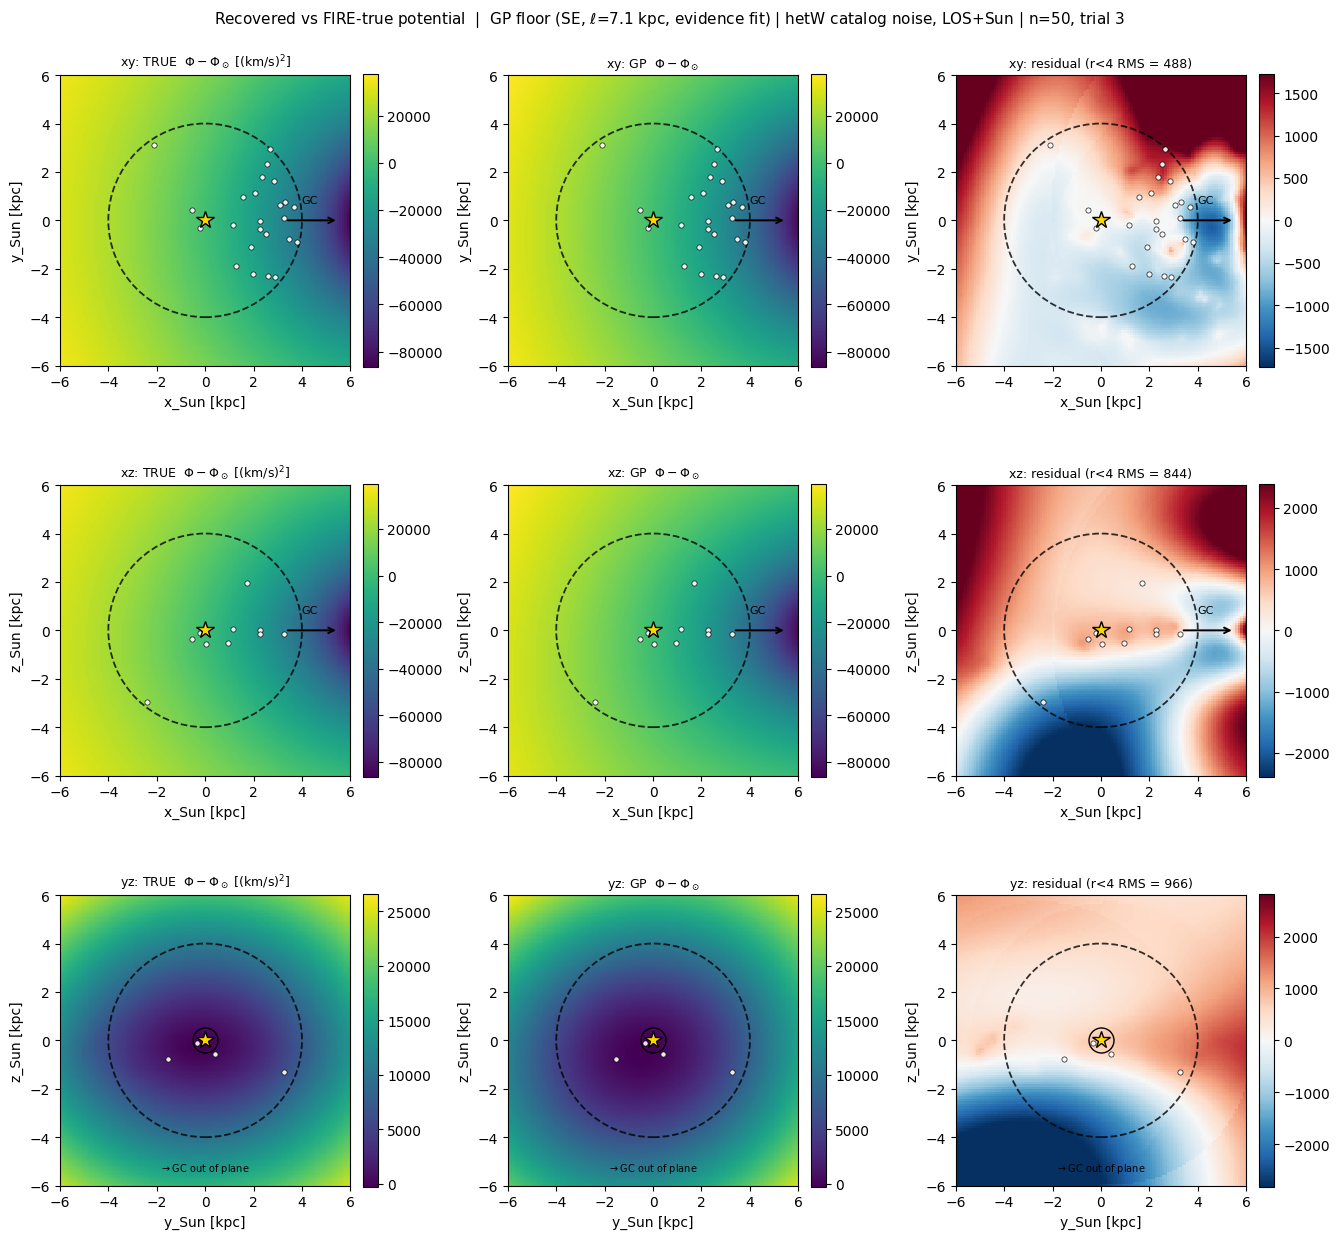

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(13.5, 12.8))
for i, name in enumerate(PLANES):
    d = F[name]
    pt = d['phi_t'] - phi_sun_t
    pp = d['phi_p'] - phi_sun_p
    rr = d['phi_p'] - d['phi_t']
    rball = np.sqrt(d['A'] ** 2 + d['B'] ** 2) <= R_TRAIN
    rr = rr - rr[rball].mean()
    rms = float(np.sqrt((rr[rball] ** 2).mean()))
    vmin, vmax = min(pt.min(), pp.min()), max(pt.max(), pp.max())
    lab0, lab1, _, gc = PLANES[name]
    pts = plane_points(name, train_xyz)
    m0 = axes[i, 0].pcolormesh(d['A'], d['B'], pt, cmap='viridis',
                               vmin=vmin, vmax=vmax, shading='auto')
    m1 = axes[i, 1].pcolormesh(d['A'], d['B'], pp, cmap='viridis',
                               vmin=vmin, vmax=vmax, shading='auto')
    rlim = np.abs(rr[rball]).max()
    m2 = axes[i, 2].pcolormesh(d['A'], d['B'], rr, cmap='RdBu_r',
                               vmin=-rlim, vmax=rlim, shading='auto')
    for j, mm in ((0, m0), (1, m1), (2, m2)):
        draw_overlays(axes[i, j], gc, pts=pts)
        axes[i, j].set_xlabel(lab0); axes[i, j].set_ylabel(lab1)
        fig.colorbar(mm, ax=axes[i, j], fraction=0.046, pad=0.04)
    axes[i, 0].set_title(
        f'{name}: TRUE  $\\Phi-\\Phi_\\odot$ [(km/s)$^2$]', fontsize=9)
    axes[i, 1].set_title(f'{name}: GP  $\\Phi-\\Phi_\\odot$', fontsize=9)
    axes[i, 2].set_title(f'{name}: residual (r<4 RMS = {rms:.0f})',
                         fontsize=9)
fig.suptitle(f'Recovered vs FIRE-true potential  |  {MODEL_TAG}',
             fontsize=11)
fig.tight_layout()
fig.savefig(FIGS / 'nb06_fig1_potential_slices.png', dpi=140)
plt.show()

### Fig 2 — Φ along rays from the Sun, now with an honest band

As in notebook 05, but the model curve carries a ±2σ band — the posterior σ
of the *gauged* difference Φ(x) − Φ(⊙), in which the data-blind additive
constant cancels. Watch the band grow with distance and fastest along the
vertical ray: that is the angle-only null space of LOS data expressed as an
error bar rather than as an unexplained residual.

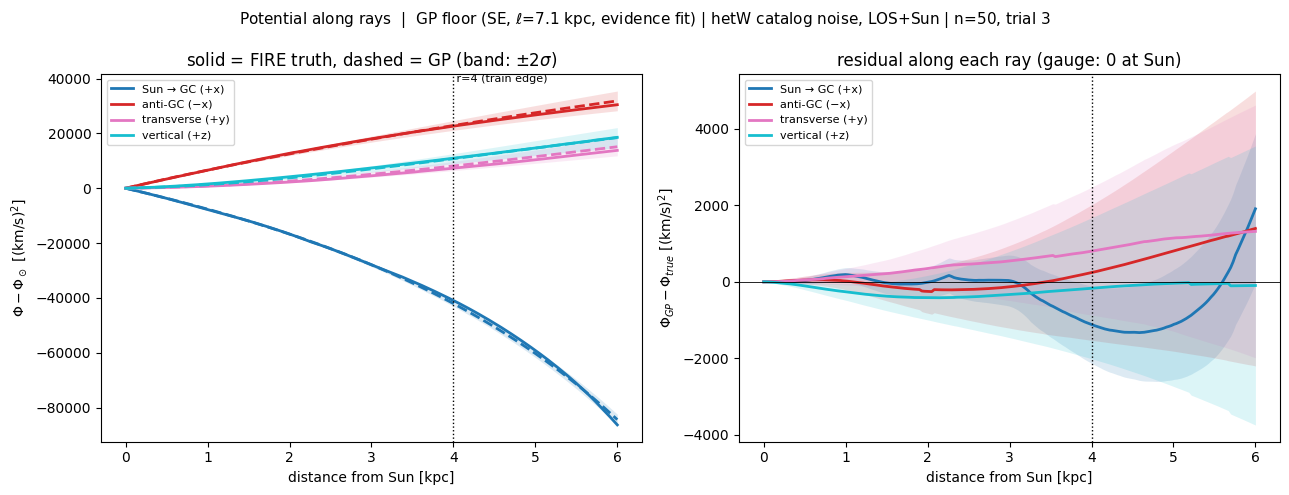

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(RAYS)))
for (k, u), col in zip(RAYS.items(), colors):
    pt = phi_ray_t[k] - phi_sun_t
    pp, ps = ray_gp[k]
    axes[0].plot(RAY_R, pt, '-', color=col, lw=2, label=RAY_LABELS[k])
    axes[0].plot(RAY_R, pp, '--', color=col, lw=2)
    axes[0].fill_between(RAY_R, pp - 2 * ps, pp + 2 * ps, color=col,
                         alpha=0.15, lw=0)
    axes[1].plot(RAY_R, pp - pt, '-', color=col, lw=2, label=RAY_LABELS[k])
    axes[1].fill_between(RAY_R, pp - pt - 2 * ps, pp - pt + 2 * ps,
                         color=col, alpha=0.15, lw=0)
for ax in axes:
    ax.axvline(R_TRAIN, color='k', ls=':', lw=1)
    ax.set_xlabel('distance from Sun [kpc]')
axes[0].text(R_TRAIN, axes[0].get_ylim()[1], ' r=4 (train edge)',
             fontsize=8, va='top')
axes[0].set_ylabel(r'$\Phi-\Phi_\odot$ [(km/s)$^2$]')
axes[0].set_title('solid = FIRE truth, dashed = GP (band: $\\pm2\\sigma$)')
axes[0].legend(fontsize=8)
axes[1].axhline(0, color='k', lw=0.6)
axes[1].set_ylabel(r'$\Phi_{GP}-\Phi_{true}$ [(km/s)$^2$]')
axes[1].set_title('residual along each ray (gauge: 0 at Sun)')
axes[1].legend(fontsize=8)
fig.suptitle(f'Potential along rays  |  {MODEL_TAG}', fontsize=11)
fig.tight_layout()
fig.savefig(FIGS / 'nb06_fig2_radial_profiles.png', dpi=140)
plt.show()

### Fig 3 — acceleration slices

The trained, gauge-free quantity in the observable's own unit. Same layout
and color handling as notebook 05 fig 3. The FIRE truth is grainy
(subhalo/GMC speckle); a smooth GP mean cannot and should not reproduce it —
the same ~5% small-scale error floor applies.

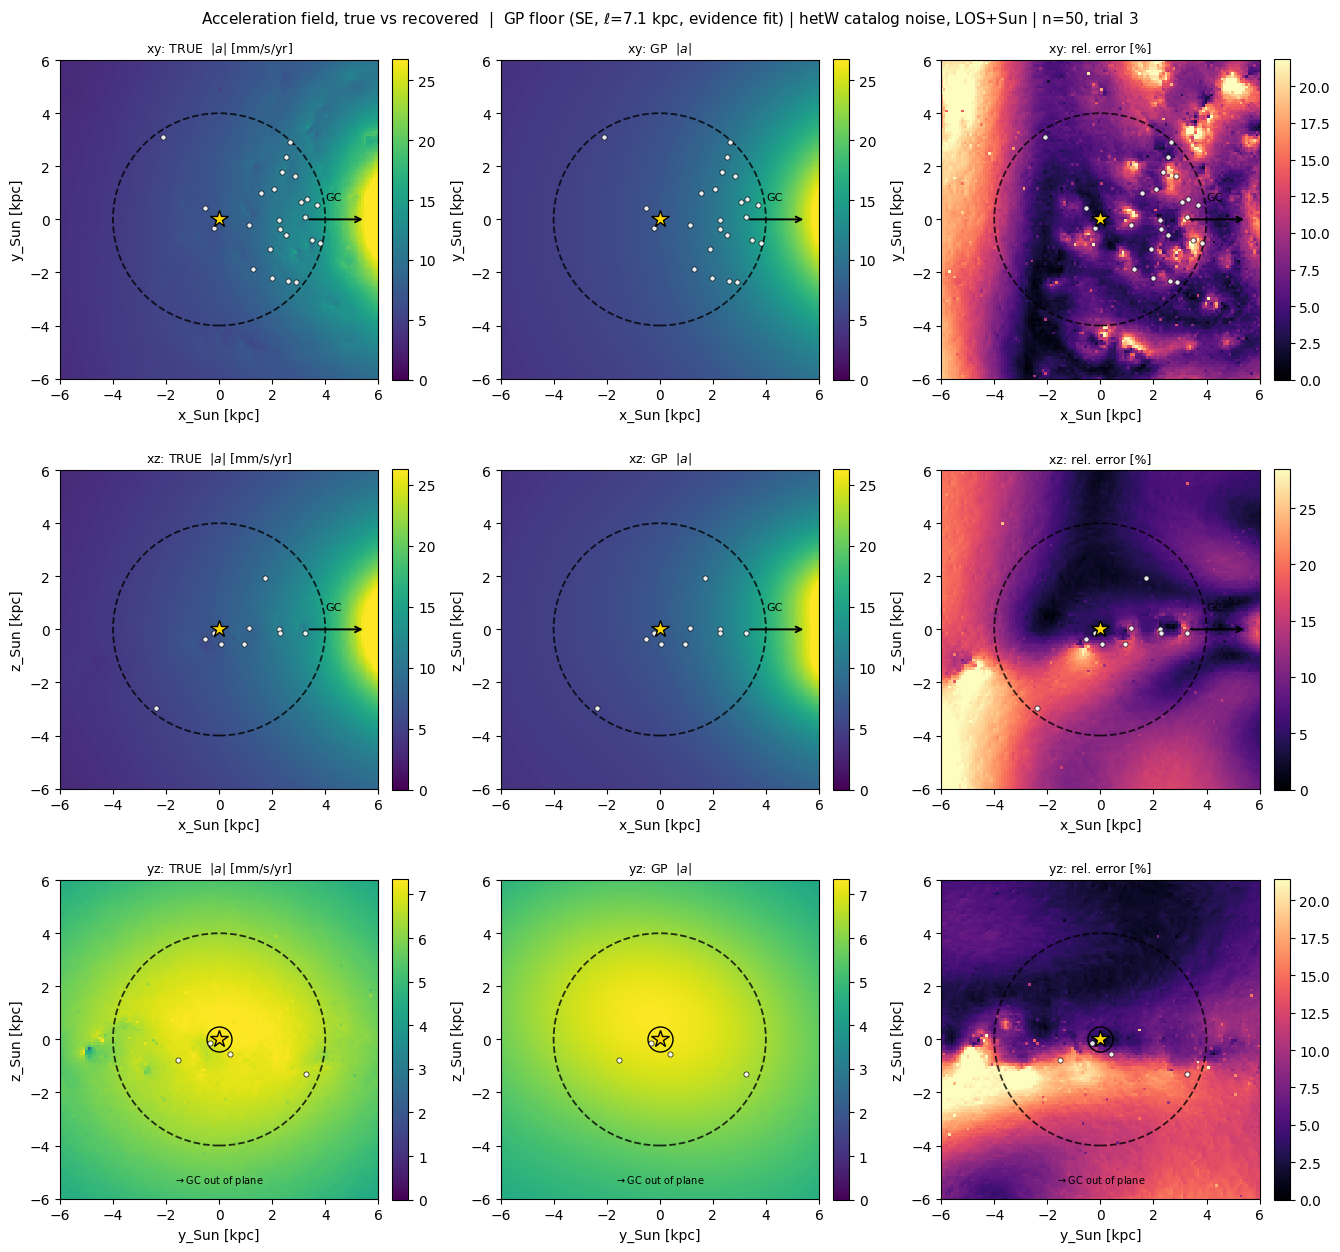

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(13.5, 12.8))
for i, name in enumerate(PLANES):
    d = F[name]
    lab0, lab1, _, gc = PLANES[name]
    pts = plane_points(name, train_xyz)
    vmax = np.percentile(d['mag_t'], 99)
    m0 = axes[i, 0].pcolormesh(d['A'], d['B'], d['mag_t'], cmap='viridis',
                               vmin=0, vmax=vmax, shading='auto')
    m1 = axes[i, 1].pcolormesh(d['A'], d['B'], d['mag_p'], cmap='viridis',
                               vmin=0, vmax=vmax, shading='auto')
    m2 = axes[i, 2].pcolormesh(d['A'], d['B'], d['err'], cmap='magma',
                               vmin=0,
                               vmax=min(60, np.percentile(d['err'], 98)),
                               shading='auto')
    for j, mm in ((0, m0), (1, m1), (2, m2)):
        draw_overlays(axes[i, j], gc, pts=pts)
        axes[i, j].set_xlabel(lab0); axes[i, j].set_ylabel(lab1)
        fig.colorbar(mm, ax=axes[i, j], fraction=0.046, pad=0.04)
    axes[i, 0].set_title(f'{name}: TRUE  $|a|$ [mm/s/yr]', fontsize=9)
    axes[i, 1].set_title(f'{name}: GP  $|a|$', fontsize=9)
    axes[i, 2].set_title(f'{name}: rel. error [%]', fontsize=9)
fig.suptitle(f'Acceleration field, true vs recovered  |  {MODEL_TAG}',
             fontsize=11)
fig.tight_layout()
fig.savefig(FIGS / 'nb06_fig3_accel_slices.png', dpi=140)
plt.show()

### Fig 4 — density slices

ρ is curvature — two derivatives from the LOS data — and the GP feels that
amplification exactly as the PINN did. Note there is **no ρ ≥ 0 constraint
here**: negative-density pixels (masked gray) are the Gaussian being honestly
Gaussian. Where the PINN's hinge discouraged ρ < 0, the GP simply reports it —
this figure *is* the argument for what only the nonlinear model can add.

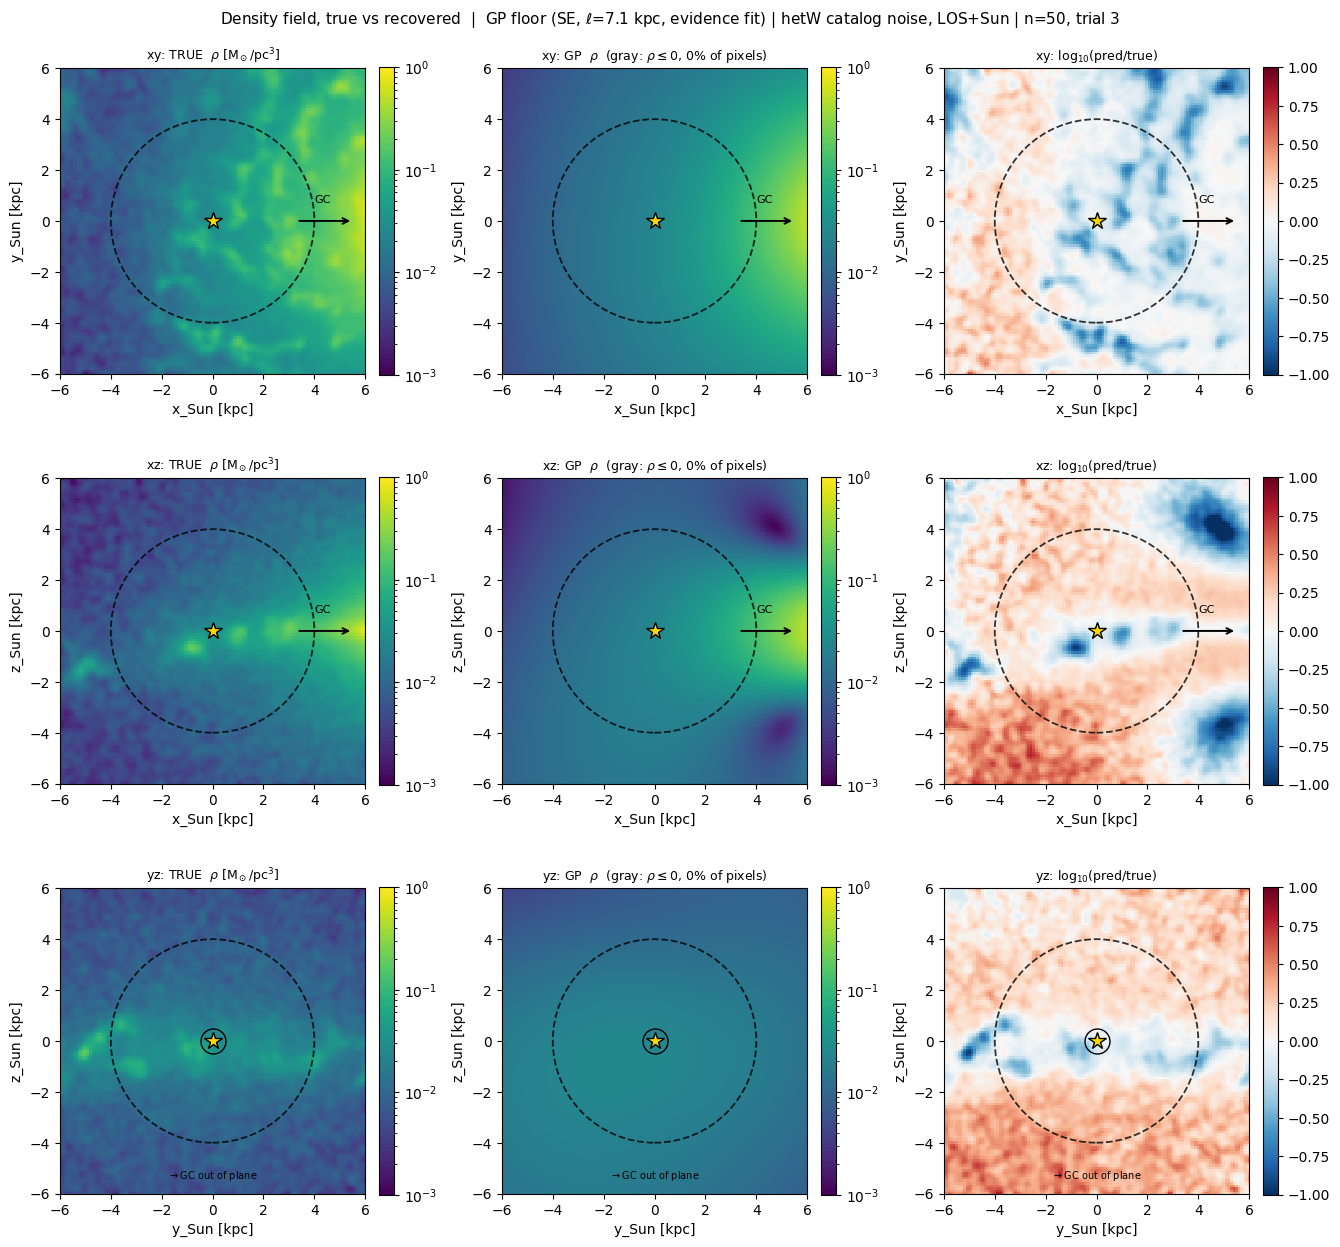

In [9]:
from matplotlib.colors import LogNorm
from scipy.ndimage import gaussian_filter

fig, axes = plt.subplots(3, 3, figsize=(13.5, 12.8))
RHO_VMIN, RHO_VMAX = 1e-3, 1
for i, name in enumerate(PLANES):
    d = F[name]
    lab0, lab1, _, gc = PLANES[name]
    rho_t = gaussian_filter(d['rho_t'], sigma=1.2)
    rho_p = np.ma.masked_less_equal(d['rho_p'], 0.0)
    neg_frac = float((d['rho_p'] <= 0).mean())
    ratio = np.ma.masked_invalid(
        np.log10(np.ma.masked_less_equal(d['rho_p'], 0)
                 / np.maximum(rho_t, 1e-6)))
    cmap_r = plt.cm.RdBu_r.copy(); cmap_r.set_bad('0.65')
    cmap_s = plt.cm.viridis.copy(); cmap_s.set_bad('0.65')
    m0 = axes[i, 0].pcolormesh(d['A'], d['B'],
                               np.maximum(rho_t, 1e-6), cmap='viridis',
                               norm=LogNorm(vmin=RHO_VMIN, vmax=RHO_VMAX),
                               shading='auto')
    m1 = axes[i, 1].pcolormesh(d['A'], d['B'], rho_p, cmap=cmap_s,
                               norm=LogNorm(vmin=RHO_VMIN, vmax=RHO_VMAX),
                               shading='auto')
    m2 = axes[i, 2].pcolormesh(d['A'], d['B'], ratio, cmap=cmap_r,
                               vmin=-1.0, vmax=1.0, shading='auto')
    for j, mm in ((0, m0), (1, m1), (2, m2)):
        draw_overlays(axes[i, j], gc)
        axes[i, j].set_xlabel(lab0); axes[i, j].set_ylabel(lab1)
        fig.colorbar(mm, ax=axes[i, j], fraction=0.046, pad=0.04)
    axes[i, 0].set_title(f'{name}: TRUE  $\\rho$ [M$_\\odot$/pc$^3$]',
                         fontsize=9)
    axes[i, 1].set_title(
        f'{name}: GP  $\\rho$  (gray: $\\rho\\leq0$, '
        f'{100 * neg_frac:.0f}% of pixels)', fontsize=9)
    axes[i, 2].set_title(f'{name}: log$_{{10}}$(pred/true)', fontsize=9)
fig.suptitle(f'Density field, true vs recovered  |  {MODEL_TAG}',
             fontsize=11)
fig.tight_layout()
fig.savefig(FIGS / 'nb06_fig4_density_slices.png', dpi=140)
plt.show()

### Fig 4b — the DM-only density, baryons assumed perfectly known

Same construction as notebook 05 fig 4b:
$\rho_{DM}^{pred} = \nabla^2\Phi_{GP}/4\pi G - \rho_b^{true}$, so every
total-density error is amplified ~3× at the midplane. The thin-disk band the
smooth prior cannot curve around shows up as masked (implied-negative) DM,
for the GP exactly as for the χ-stopped PINN.

/var/folders/qq/_c3h3m7x0cj6f8qprnj5kyjw0000gq/T/ipykernel_70265/1335284228.py:11: RuntimeWarning: invalid value encountered in log10
  ratio = np.ma.masked_invalid(np.log10(dm_p / np.maximum(dm_t, 1e-6)))


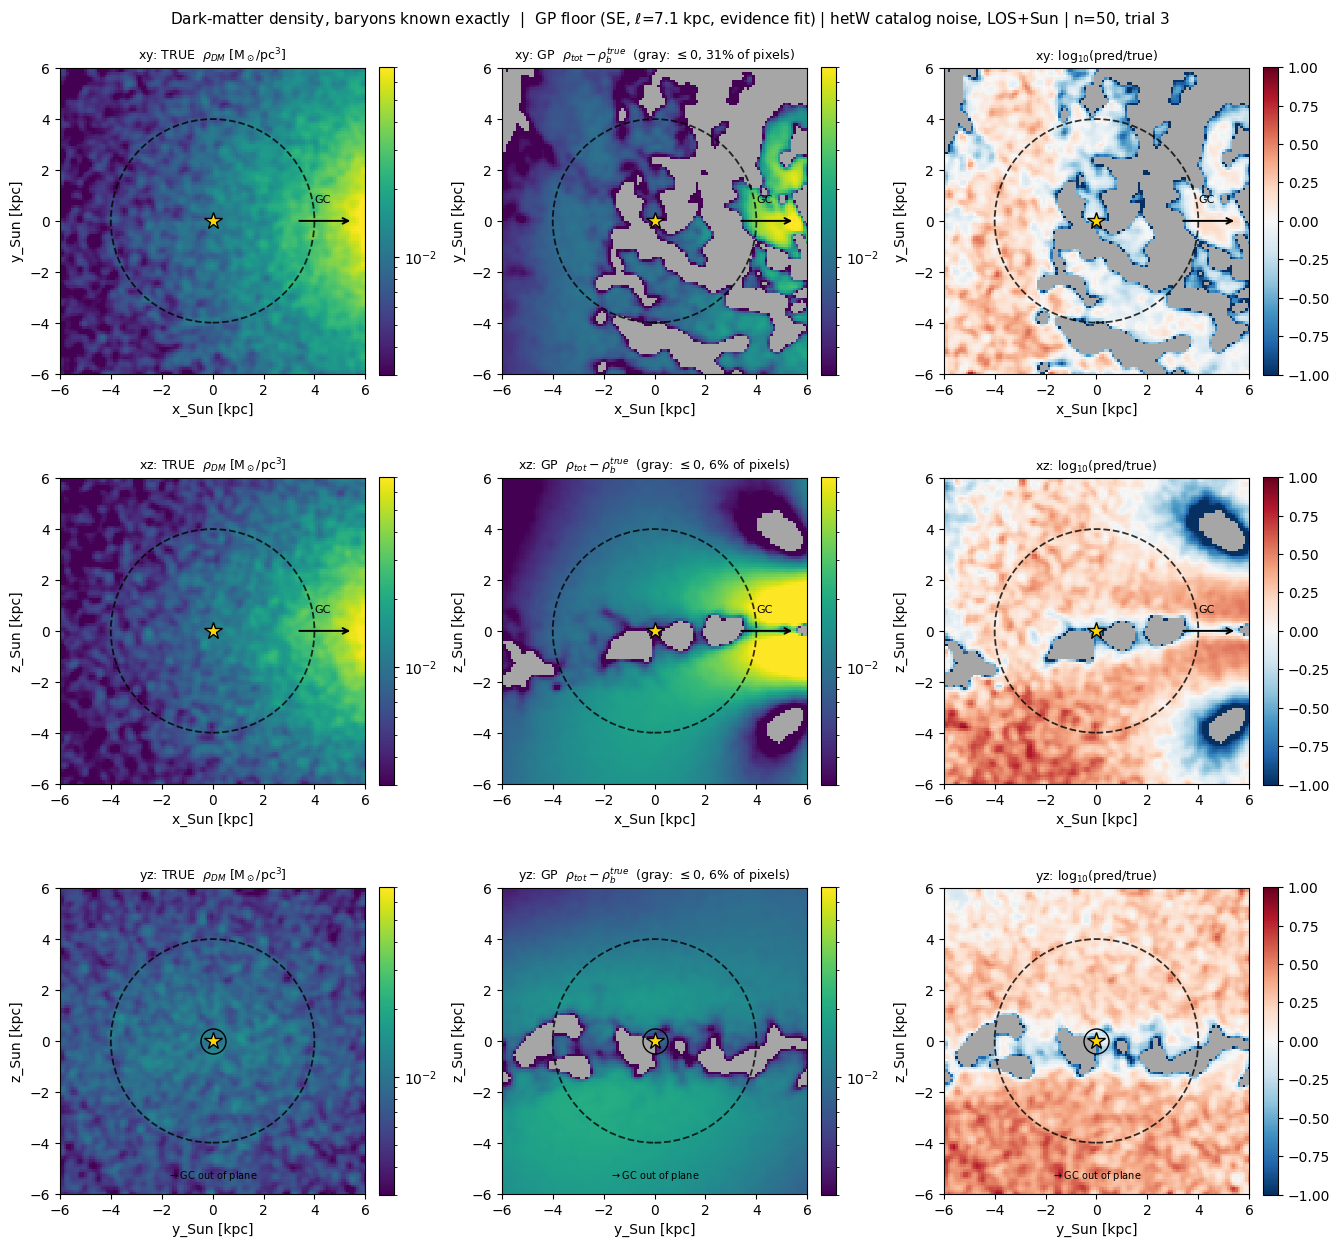

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(13.5, 12.8))
RHO_VMIN_DM = 3e-3; RHO_VMAX_DM = 7e-2
for i, name in enumerate(PLANES):
    d = F[name]
    lab0, lab1, _, gc = PLANES[name]
    dm_t = gaussian_filter(d['rho_dark'], sigma=1.2)
    bary_t = gaussian_filter(d['rho_bary'], sigma=1.2)
    dm_raw = d['rho_p'] - bary_t
    neg_frac = float((dm_raw <= 0).mean())
    dm_p = np.ma.masked_less_equal(dm_raw, 0.0)
    ratio = np.ma.masked_invalid(np.log10(dm_p / np.maximum(dm_t, 1e-6)))
    cmap_r = plt.cm.RdBu_r.copy(); cmap_r.set_bad('0.65')
    cmap_s = plt.cm.viridis.copy(); cmap_s.set_bad('0.65')
    m0 = axes[i, 0].pcolormesh(d['A'], d['B'], np.maximum(dm_t, 1e-6),
                               cmap='viridis',
                               norm=LogNorm(vmin=RHO_VMIN_DM,
                                            vmax=RHO_VMAX_DM),
                               shading='auto')
    m1 = axes[i, 1].pcolormesh(d['A'], d['B'], dm_p, cmap=cmap_s,
                               norm=LogNorm(vmin=RHO_VMIN_DM,
                                            vmax=RHO_VMAX_DM),
                               shading='auto')
    m2 = axes[i, 2].pcolormesh(d['A'], d['B'], ratio, cmap=cmap_r,
                               vmin=-1.0, vmax=1.0, shading='auto')
    for j, mm in ((0, m0), (1, m1), (2, m2)):
        draw_overlays(axes[i, j], gc)
        axes[i, j].set_xlabel(lab0); axes[i, j].set_ylabel(lab1)
        fig.colorbar(mm, ax=axes[i, j], fraction=0.046, pad=0.04)
    axes[i, 0].set_title(
        f'{name}: TRUE  $\\rho_{{DM}}$ [M$_\\odot$/pc$^3$]', fontsize=9)
    axes[i, 1].set_title(
        f'{name}: GP  $\\rho_{{tot}}-\\rho_b^{{true}}$  '
        f'(gray: $\\leq0$, {100 * neg_frac:.0f}% of pixels)', fontsize=9)
    axes[i, 2].set_title(f'{name}: log$_{{10}}$(pred/true)', fontsize=9)
fig.suptitle(f'Dark-matter density, baryons known exactly  |  {MODEL_TAG}',
             fontsize=11)
fig.tight_layout()
fig.savefig(FIGS / 'nb06_fig4b_density_dm_slices.png', dpi=140)
plt.show()

### Fig 5 — the vertical density profile at the solar annulus

Notebook 05 fig 5 with the GP curve and its pointwise ±2σ band (azimuthally
averaged over the ring). The gap at |z| ≲ 0.3 kpc is the thin disk again —
and note whether the truth sits *inside* the band there: if it does not, the
discrepancy is a statement about the *prior class* (an isotropic few-kpc SE
kernel contains no 0.3-kpc disk), not about the noise level. That is
model-*mis*specification showing up exactly where it should.

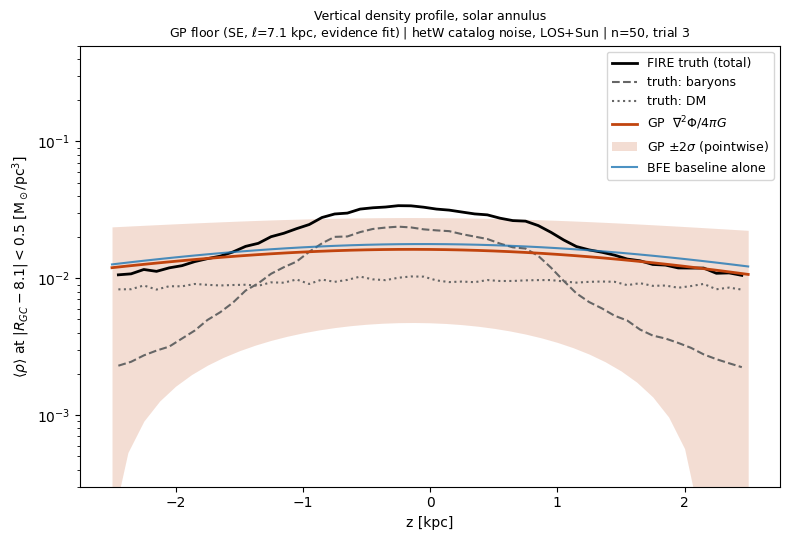

midplane: truth 0.033, GP 0.016 +- 0.006, BFE 0.018 Msun/pc^3


In [11]:
zcent = 0.5 * (ZEDGES[1:] + ZEDGES[:-1])
rz_bary = zc['rhoz|gas'] + zc['rhoz|star']
rz_dark = zc['rhoz|dark']
rz_tot = rz_bary + rz_dark

zgrid = np.linspace(-2.5, 2.5, 41)
phis = np.linspace(0, 2 * np.pi, 24, endpoint=False)
ring = np.stack([8.1 * np.cos(phis), 8.1 * np.sin(phis)], axis=1)
pts = np.concatenate([np.column_stack([ring[:, 0], ring[:, 1],
                                       np.full(len(ring), zv)])
                      for zv in zgrid])
rho_ring, sig_ring = rho_gp_msun_pc3(pts)
rho_model_z = rho_ring.reshape(len(zgrid), -1).mean(axis=1)
sig_model_z = sig_ring.reshape(len(zgrid), -1).mean(axis=1)
rho_bfe_z = bfe_rho_msun_pc3(pts).reshape(len(zgrid), -1).mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.semilogy(zcent, rz_tot, '-', color='k', lw=2, label='FIRE truth (total)')
ax.semilogy(zcent, rz_bary, '--', color='0.4', lw=1.5,
            label='truth: baryons')
ax.semilogy(zcent, rz_dark, ':', color='0.4', lw=1.5, label='truth: DM')
ax.semilogy(zgrid, np.clip(rho_model_z, 1e-5, None), '-', color='#c1440e',
            lw=2, label='GP  $\\nabla^2\\Phi/4\\pi G$')
ax.fill_between(zgrid, np.clip(rho_model_z - 2 * sig_model_z, 1e-5, None),
                np.clip(rho_model_z + 2 * sig_model_z, 1e-5, None),
                color='#c1440e', alpha=0.18, lw=0,
                label='GP $\\pm2\\sigma$ (pointwise)')
ax.semilogy(zgrid, np.clip(rho_bfe_z, 1e-5, None), '-', color='#1f77b4',
            lw=1.5, alpha=0.8, label='BFE baseline alone')
ax.set_xlabel('z [kpc]')
ax.set_ylabel(r'$\langle\rho\rangle$ at $|R_{GC}-8.1|<0.5$ '
              r'[M$_\odot$/pc$^3$]')
ax.set_ylim(3e-4, 0.5)
ax.legend(fontsize=9)
ax.set_title(f'Vertical density profile, solar annulus\n{MODEL_TAG}',
             fontsize=9)
fig.tight_layout()
fig.savefig(FIGS / 'nb06_fig5_rho_z_profile.png', dpi=140)
plt.show()
i0 = np.abs(zgrid).argmin()
print(f'midplane: truth {rz_tot[np.abs(zcent).argmin()]:.3f}, '
      f'GP {rho_model_z[i0]:.3f} +- {sig_model_z[i0]:.3f}, '
      f'BFE {rho_bfe_z[i0]:.3f} Msun/pc^3')

### Fig 6 — the observing geometry

Identical to notebook 05 fig 6 by construction — the replay gate above proved
these are the same 50 sightlines and σ's the PINN saw. Kept so this notebook
stands alone in talks.

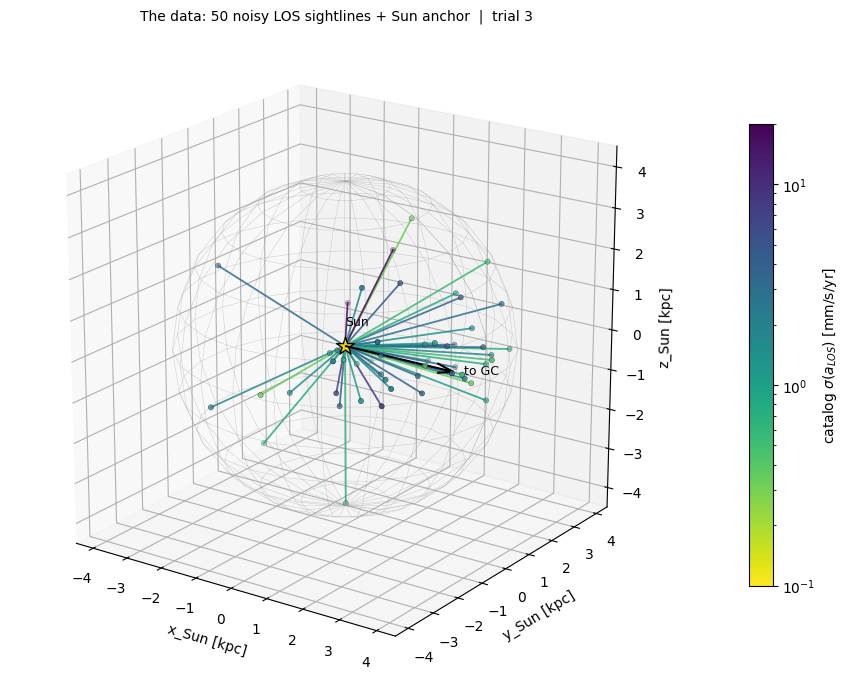

In [12]:
from matplotlib.colors import LogNorm as _LogNorm
from matplotlib import cm as _cm

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection='3d')
p_sun = train_xyz - OBSERVER
snorm = _LogNorm(vmin=0.1, vmax=20.0)
cmap = plt.cm.viridis_r
for i in range(N_TRAIN):
    ax.plot([0, p_sun[i, 0]], [0, p_sun[i, 1]], [0, p_sun[i, 2]],
            color=cmap(snorm(sig_i[i])), lw=1.3, alpha=0.85)
ax.scatter(p_sun[:, 0], p_sun[:, 1], p_sun[:, 2], s=14,
           c=sig_i, cmap=cmap, norm=snorm, edgecolor='k', lw=0.3)
uu, vv = np.meshgrid(np.linspace(0, 2 * np.pi, 24),
                     np.linspace(0, np.pi, 13))
ax.plot_wireframe(R_TRAIN * np.cos(uu) * np.sin(vv),
                  R_TRAIN * np.sin(uu) * np.sin(vv),
                  R_TRAIN * np.cos(vv), color='0.6', lw=0.4, alpha=0.4)
ax.scatter([0], [0], [0], marker='*', s=180, c='gold', edgecolor='k',
           zorder=9)
ax.text(0, 0, 0.5, 'Sun', fontsize=9)
ax.quiver(0, 0, 0, 3.0, 0, 0, color='k', arrow_length_ratio=0.15, lw=1.5)
ax.text(3.3, 0, 0, 'to GC', fontsize=9)
sm = _cm.ScalarMappable(norm=snorm, cmap=cmap)
fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.1,
             label=r'catalog $\sigma(a_{LOS})$ [mm/s/yr]')
ax.set_xlabel('x_Sun [kpc]'); ax.set_ylabel('y_Sun [kpc]')
ax.set_zlabel('z_Sun [kpc]')
lim3 = 4.5
ax.set_xlim(-lim3, lim3); ax.set_ylim(-lim3, lim3); ax.set_zlim(-lim3, lim3)
ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=20, azim=-55)
ax.set_title(f'The data: {N_TRAIN} noisy LOS sightlines + Sun anchor  |  '
             f'trial {TRIAL}', fontsize=10)
fig.tight_layout()
fig.savefig(FIGS / 'nb06_fig6_3d_geometry.png', dpi=140)
plt.show()

### Fig 7 — the error field in 3-D

Notebook 05 fig 7 with the GP's errors: the through-Sun |a|-error slices on
the box faces, and the sun15 validation cloud colored by per-star error. The
anisotropic growth pattern outside the ball (transverse directions first) is
the sightline geometry's null space — model-independent, as promised.

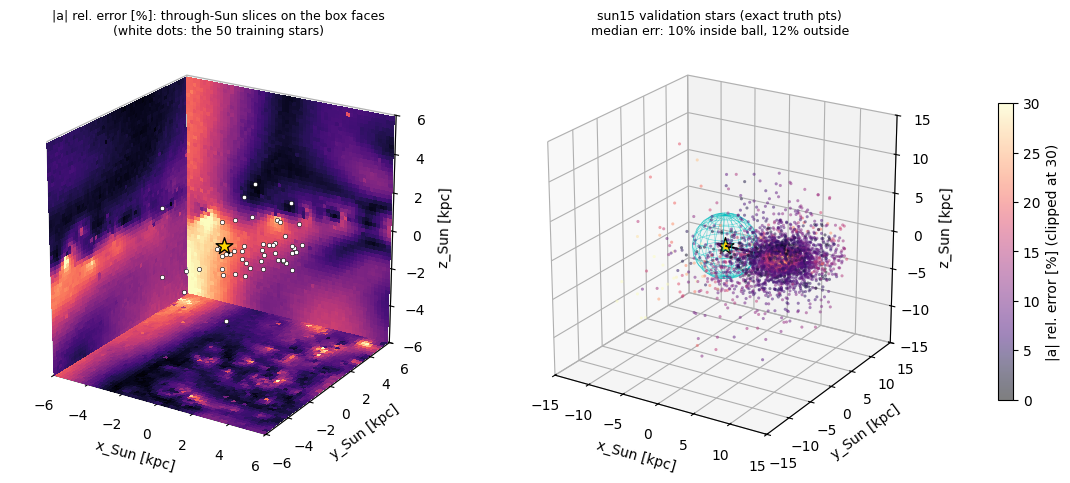

In [13]:
from matplotlib.colors import Normalize

enorm = Normalize(vmin=0, vmax=30)
fig = plt.figure(figsize=(15, 7))

ax = fig.add_subplot(121, projection='3d')
ax.computed_zorder = False
st = 2
for name, (fix, sgn) in {'xy': ('z', -1), 'xz': ('y', +1),
                         'yz': ('x', -1)}.items():
    d = F[name]
    A, B, E = d['A'][::st, ::st], d['B'][::st, ::st], d['err'][::st, ::st]
    Cface = plt.cm.magma(enorm(E))
    flat = np.full_like(A, sgn * LIM)
    if name == 'xy':
        X, Y, Z = A, B, flat
    elif name == 'xz':
        X, Y, Z = A, flat, B
    else:
        X, Y, Z = flat, A, B
    ax.plot_surface(X, Y, Z, facecolors=Cface, shade=False, rstride=1,
                    cstride=1, linewidth=0, antialiased=False, zorder=1)
ax.scatter(p_sun[:, 0], p_sun[:, 1], p_sun[:, 2], s=10, c='w',
           edgecolor='k', lw=0.4, depthshade=False, zorder=10)
ax.scatter([0], [0], [0], marker='*', s=160, c='gold', edgecolor='k',
           zorder=11)
ax.set_xlabel('x_Sun [kpc]'); ax.set_ylabel('y_Sun [kpc]')
ax.set_zlabel('z_Sun [kpc]')
ax.set_xlim(-LIM, LIM); ax.set_ylim(-LIM, LIM); ax.set_zlim(-LIM, LIM)
ax.set_box_aspect((1, 1, 1)); ax.view_init(elev=22, azim=-58)
ax.set_title(f'|a| rel. error [%]: through-Sun slices on the box faces\n'
             f'(white dots: the {N_TRAIN} training stars)', fontsize=9)

ax2 = fig.add_subplot(122, projection='3d')
pv = xv15 - OBSERVER
sc = ax2.scatter(pv[:, 0], pv[:, 1], pv[:, 2], c=np.clip(err15, 0, 30),
                 cmap='magma', norm=enorm, s=5, alpha=0.5, lw=0)
ax2.plot_wireframe(R_TRAIN * np.cos(uu) * np.sin(vv),
                   R_TRAIN * np.sin(uu) * np.sin(vv),
                   R_TRAIN * np.cos(vv), color='c', lw=0.5, alpha=0.5)
ax2.scatter([0], [0], [0], marker='*', s=160, c='gold', edgecolor='k')
ax2.quiver(0, 0, 0, 5, 0, 0, color='k', arrow_length_ratio=0.1, lw=1.5)
ax2.text(5.5, 0, 0, 'GC', fontsize=9)
in4 = np.linalg.norm(pv, axis=1) < R_TRAIN
ax2.set_title(f'sun15 validation stars (exact truth pts)\n'
              f'median err: {np.median(err15[in4]):.0f}% inside ball, '
              f'{np.median(err15[~in4]):.0f}% outside', fontsize=9)
ax2.set_xlabel('x_Sun [kpc]'); ax2.set_ylabel('y_Sun [kpc]')
ax2.set_zlabel('z_Sun [kpc]')
lim15 = 15.0
ax2.set_xlim(-lim15, lim15); ax2.set_ylim(-lim15, lim15)
ax2.set_zlim(-lim15, lim15)
ax2.set_box_aspect((1, 1, 1)); ax2.view_init(elev=22, azim=-58)
fig.colorbar(sc, ax=[ax, ax2], shrink=0.55, pad=0.06,
             label='|a| rel. error [%] (clipped at 30)')
fig.savefig(FIGS / 'nb06_fig7_3d_error_field.png', dpi=140)
plt.show()

### Fig 8 — what the NN cannot draw: the posterior σ field, tested

Left/middle: the GP's own predicted uncertainty for the acceleration (total
component σ, mm/s/yr) and for ρ (M☉/pc³) on the disk plane — watch σ collapse
around the sightline bundle and grow toward the prior far from it. Right: the
test. If the σ's are honest, the per-component z-scores
$(a_{GP} - a_{true})/\sigma$ should be standard-normal. In-ball they are
overdispersed by a factor ~2 (a single isotropic SE kernel is still too
rigid for FIRE's granularity — real but mild); on the 15-kpc shell they are
overdispersed by ~10× — the *stationary* prior, whose amplitude was
calibrated inside the 4-kpc data ball, does not know that the BFE residual
keeps growing outside it. Closed-form error bars are only as honest as the
prior class; this is the sun-sphere extrapolation plateau, restated as a
calibration failure you can see.

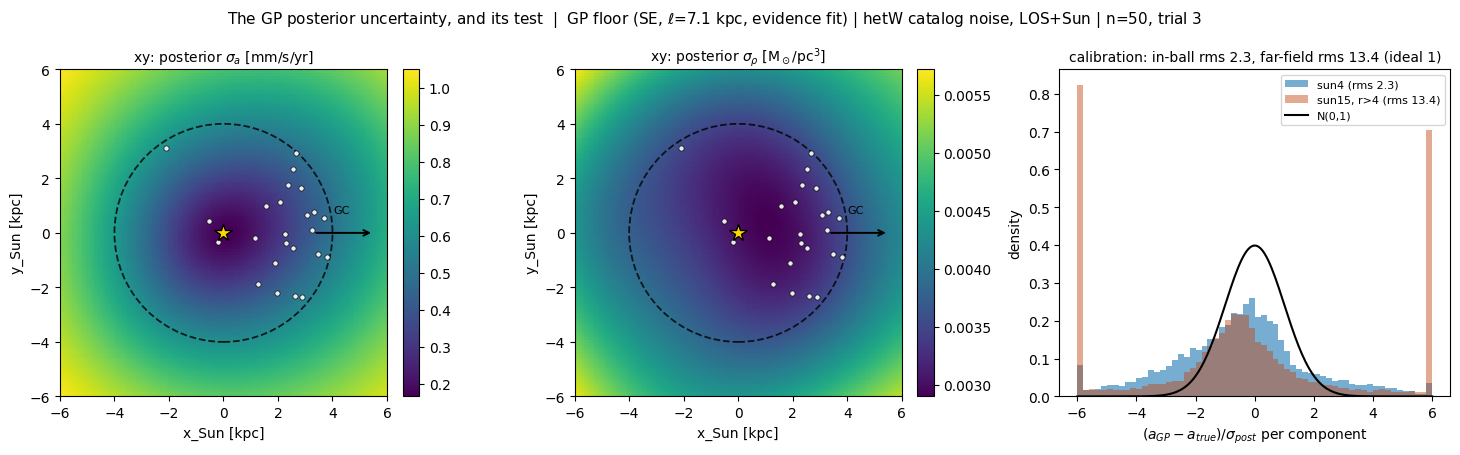

In [14]:
fig = plt.figure(figsize=(15, 4.6))
d = F['xy']
ax1 = fig.add_subplot(131)
m1 = ax1.pcolormesh(d['A'], d['B'], d['sig_a'], cmap='viridis',
                    shading='auto')
draw_overlays(ax1, 'arrow', pts=plane_points('xy', train_xyz))
fig.colorbar(m1, ax=ax1, fraction=0.046, pad=0.04)
ax1.set_title(r'xy: posterior $\sigma_a$ [mm/s/yr]', fontsize=10)
ax1.set_xlabel('x_Sun [kpc]'); ax1.set_ylabel('y_Sun [kpc]')

ax2 = fig.add_subplot(132)
m2 = ax2.pcolormesh(d['A'], d['B'], d['rho_sig'], cmap='viridis',
                    shading='auto')
draw_overlays(ax2, 'arrow', pts=plane_points('xy', train_xyz))
fig.colorbar(m2, ax=ax2, fraction=0.046, pad=0.04)
ax2.set_title(r'xy: posterior $\sigma_\rho$ [M$_\odot$/pc$^3$]', fontsize=10)
ax2.set_xlabel('x_Sun [kpc]'); ax2.set_ylabel('y_Sun [kpc]')

ax3 = fig.add_subplot(133)
bins = np.linspace(-6, 6, 61)
xv4, av4 = val['sun4']
z4 = ((err_cloud['sun4'][1] - av4) / np.sqrt(err_cloud['sun4'][2])).ravel()
dist15 = np.linalg.norm(val['sun15'][0] - OBSERVER, axis=1)
z15 = ((err_cloud['sun15'][1] - val['sun15'][1])
       / np.sqrt(err_cloud['sun15'][2]))[dist15 > R_TRAIN].ravel()
ax3.hist(np.clip(z4, -6, 6), bins=bins, density=True, alpha=0.6,
         color='#1f77b4', label=f'sun4 (rms {z4.std():.1f})')
ax3.hist(np.clip(z15, -6, 6), bins=bins, density=True, alpha=0.45,
         color='#c1440e', label=f'sun15, r>4 (rms {z15.std():.1f})')
xx = np.linspace(-6, 6, 200)
ax3.plot(xx, np.exp(-xx ** 2 / 2) / np.sqrt(2 * np.pi), 'k-', lw=1.5,
         label='N(0,1)')
ax3.set_xlabel(r'$(a_{GP}-a_{true})/\sigma_{post}$ per component')
ax3.set_ylabel('density')
ax3.legend(fontsize=8)
ax3.set_title(f'calibration: in-ball rms {z4.std():.1f}, '
              f'far-field rms {z15.std():.1f} (ideal 1)', fontsize=10)
fig.suptitle(f'The GP posterior uncertainty, and its test  |  {MODEL_TAG}',
             fontsize=11)
fig.tight_layout()
fig.savefig(FIGS / 'nb06_fig8_uncertainty_calibration.png', dpi=140)
plt.show()

## Fig 9 — where should the next measurement point?

The question "which new sightline would teach us the most?" has a tempting
wrong answer and a closed-form right one.

**The wrong answer** is gradient-of-the-loss with respect to inputs. For a
fitted model $\partial L/\partial x_i \propto r_i$ (the residual), so its
expectation under a correct model is *zero* and maximizing it is residual
chasing — on the real catalog it selects exactly the |χ| ≈ 10 systematics
outliers (`experiments/gp_audit/REPORT.md`). And a *future* measurement's
position never appears in the loss at all.

**The right object** is the expected reduction in posterior variance of a
*named* science target (c-optimality — a whole-sky "most uncertain point" map
is degenerate for a stationary kernel and answers no scientific question).
Target here: **ρ at the Sun**. Because the observable is linear in Φ, the
posterior variance is data-value-free (§theory above), so a hypothetical new
pulsar at $(\ell, b)$, distance $d$, precision σ is scored *before it is
measured* by one rank-1 update:

$$\mathrm{Var}_{new} = \mathrm{Var}_{53} -
\frac{\left(c_{t,new} - c_t^\top C^{-1} k_{new}\right)^2}
     {v_{new} + \sigma_{new}^2 - k_{new}^\top C^{-1} k_{new}},
\qquad \Delta\mathrm{bits} = \tfrac12\log_2
\frac{\mathrm{Var}_{53}}{\mathrm{Var}_{new}}.$$

The numerator is the candidate's covariance with the target *after*
projecting out what the existing 53 rows already know — redundancy is
penalized automatically (re-measuring our single best pulsar at its own
precision is worth several times less than the best new pointing; the
printout quantifies it). No gradient ascent is needed: the whole sky is scored
exhaustively in ~0.1 s. Physics to expect: the local Laplacian is dominated
by $\partial a_z/\partial z$, so **vertical, nearby, precise** sightlines
should win — and the map should avoid the directions the 50 draws already
cover. $(\ell, b)$ are simulation-frame galactic coordinates
($\ell=0$ toward the GC, $b=90°$ along $+z$).

Caveats that keep the figure honest: the map is conditional on the SE prior
(a different kernel moves the details, not the verticality logic), it scores
*one* added measurement (batch design would iterate greedily), and σ is
treated as free — the bottom panel shows the map collapsing as σ approaches
the catalog median, which is the N_eff ≈ 3.5 lesson of the real catalog: *how
precisely* you measure matters more than *where*.

sigma(rho_sun): prior 0.0075 -> posterior 0.0030 Msun/pc^3  (1.31 bits from the 53 rows)
redundancy check — duplicating the most precise existing pulsar: 0.0392 bits


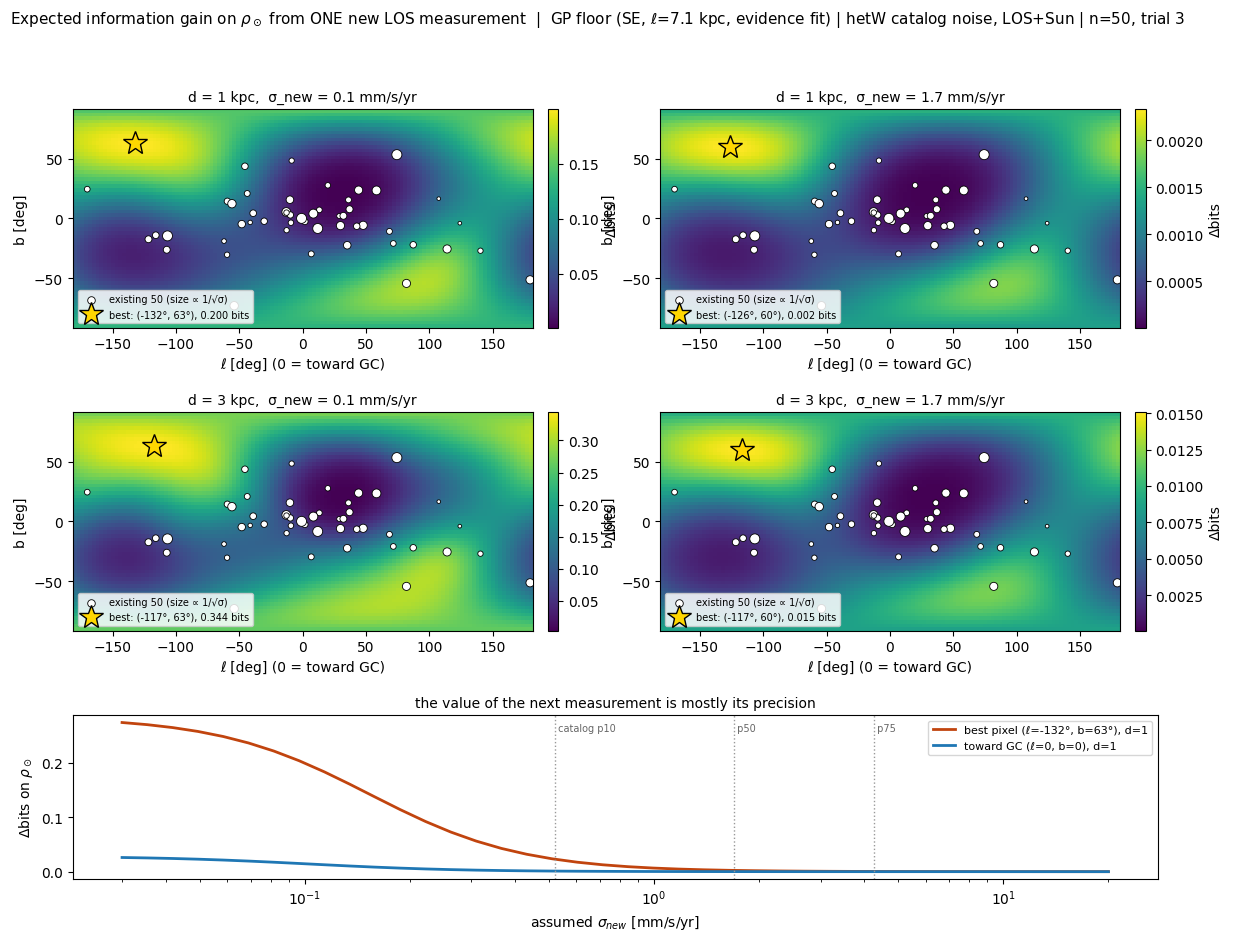

best single addition (d=1 kpc, sigma=0.1): (l=-132, b=63) -> 0.200 bits; sigma(rho_sun) 0.0030 -> 0.0026 Msun/pc^3
existing sky coverage: 52% of sightlines at |b|<15 deg, 2% at |b|>60 deg


In [15]:
# target: rho at the Sun  (BFE part is deterministic -> variance is on dPhi)
P, U, nvar, alpha, L = GP['P'], GP['U'], GP['nvar'], GP['alpha'], GP['L']
cho = lambda b: jax.scipy.linalg.cho_solve((L, True), b)
x_sun_j = jnp.asarray(X_SUN)

c_t = A2 * jax.vmap(lambda p, u: cov_lap_row(x_sun_j, p, u, ELL))(P, U)
v_t = A2 * float(lap_lap0(ELL))
beta = cho(c_t)
var_now = v_t - float(jnp.dot(c_t, beta))
to_sd = lambda v: np.sqrt(v) / FOUR_PI_G * TO_MSUN_PC3
print(f'sigma(rho_sun): prior {to_sd(v_t):.4f} -> posterior '
      f'{to_sd(var_now):.4f} Msun/pc^3  '
      f'({0.5 * np.log2(v_t / var_now):.2f} bits from the 53 rows)')

@jax.jit
def delta_bits(p_new, u_new, s2_new):
    k_n = A2 * jax.vmap(lambda p, u: cov_rr(p_new, u_new, p, u, ELL))(P, U)
    c_tn = A2 * cov_lap_row(x_sun_j, p_new, u_new, ELL)
    num = (c_tn - jnp.dot(k_n, beta)) ** 2
    den = A2 / ELL ** 2 + s2_new - jnp.dot(k_n, cho(k_n))
    return 0.5 * jnp.log2(var_now / (var_now - num / den))

i_best = int(np.argmin(np.asarray(nvar)[:N_TRAIN]))
print(f'redundancy check — duplicating the most precise existing pulsar: '
      f'{float(delta_bits(P[i_best], U[i_best], nvar[i_best])):.4f} bits')

def sky_map(d_kpc, sig_mmsyr, nl=121, nb=61):
    ls, bs = np.linspace(-180, 180, nl), np.linspace(-90, 90, nb)
    Lg, Bg = np.meshgrid(np.deg2rad(ls), np.deg2rad(bs))
    nhat = np.stack([np.cos(Bg) * np.cos(Lg), np.cos(Bg) * np.sin(Lg),
                     np.sin(Bg)], axis=-1).reshape(-1, 3)
    s2 = (sig_mmsyr * MMSYR_TO_KPCMYR2) ** 2
    db = jax.vmap(lambda p, u: delta_bits(p, u, s2))(
        jnp.asarray(OBSERVER + d_kpc * nhat), jnp.asarray(nhat))
    db = np.asarray(db).reshape(nb, nl)
    assert (db >= -1e-9).all(), 'information gain must be non-negative'
    return ls, bs, db

nv = GP['rows']['nv']
gal_l = np.rad2deg(np.arctan2(nv[:, 1], nv[:, 0]))
gal_b = np.rad2deg(np.arcsin(np.clip(nv[:, 2], -1, 1)))

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 2, height_ratios=(1, 1, 0.75), hspace=0.42,
                      wspace=0.18)
best = {}
for k, (dk, sk) in enumerate([(1.0, 0.1), (1.0, 1.7),
                              (3.0, 0.1), (3.0, 1.7)]):
    ax = fig.add_subplot(gs[k // 2, k % 2])
    ls, bs, db = sky_map(dk, sk)
    mm = ax.pcolormesh(ls, bs, db, cmap='viridis', shading='auto')
    ax.scatter(gal_l, gal_b, s=30 / np.sqrt(sig_i), c='w', edgecolor='k',
               lw=0.6, zorder=5, label='existing 50 (size ∝ 1/√σ)')
    i, j = np.unravel_index(db.argmax(), db.shape)
    ax.plot(ls[j], bs[i], '*', color='gold', mec='k', ms=18, zorder=6,
            label=f'best: ({ls[j]:.0f}°, {bs[i]:.0f}°), {db.max():.3f} bits')
    best[(dk, sk)] = (ls[j], bs[i], db.max())
    fig.colorbar(mm, ax=ax, fraction=0.046, pad=0.03, label='Δbits')
    ax.set_xlabel('ℓ [deg] (0 = toward GC)'); ax.set_ylabel('b [deg]')
    ax.set_title(f'd = {dk:.0f} kpc,  σ_new = {sk} mm/s/yr', fontsize=10)
    ax.legend(fontsize=7, loc='lower left', framealpha=0.85)

axc = fig.add_subplot(gs[2, :])
lb, bb, _ = best[(1.0, 0.1)]
nb_best = np.array([np.cos(np.deg2rad(bb)) * np.cos(np.deg2rad(lb)),
                    np.cos(np.deg2rad(bb)) * np.sin(np.deg2rad(lb)),
                    np.sin(np.deg2rad(bb))])
sigs = np.geomspace(0.03, 20.0, 40)
for nvec, lab, col in [
        (nb_best, f'best pixel (ℓ={lb:.0f}°, b={bb:.0f}°), d=1', '#c1440e'),
        (np.array([1.0, 0, 0]), 'toward GC (ℓ=0, b=0), d=1', '#1f77b4')]:
    dbs = [float(delta_bits(jnp.asarray(OBSERVER + 1.0 * nvec),
                            jnp.asarray(nvec),
                            (s * MMSYR_TO_KPCMYR2) ** 2)) for s in sigs]
    axc.semilogx(sigs, dbs, '-', lw=2, color=col, label=lab)
for s, lab in [(0.52, 'catalog p10'), (1.69, 'p50'), (4.26, 'p75')]:
    axc.axvline(s, color='0.6', ls=':', lw=1)
    axc.text(s, axc.get_ylim()[1] * 0.95, f' {lab}', fontsize=7,
             va='top', color='0.4')
axc.set_xlabel(r'assumed $\sigma_{new}$ [mm/s/yr]')
axc.set_ylabel(r'$\Delta$bits on $\rho_\odot$')
axc.legend(fontsize=8)
axc.set_title('the value of the next measurement is mostly its precision',
              fontsize=10)
fig.suptitle(f'Expected information gain on $\\rho_\\odot$ from ONE new LOS '
             f'measurement  |  {MODEL_TAG}', fontsize=11)
fig.savefig(FIGS / 'nb06_fig9_information_skymap.png', dpi=140,
            bbox_inches='tight')
plt.show()

lb_, bb_, db_ = best[(1.0, 0.1)]
print(f'best single addition (d=1 kpc, sigma=0.1): (l={lb_:.0f}, b={bb_:.0f})'
      f' -> {db_:.3f} bits; sigma(rho_sun) {to_sd(var_now):.4f} -> '
      f'{to_sd(var_now / 2 ** (2 * db_)):.4f} Msun/pc^3')
print(f'existing sky coverage: {(np.abs(gal_b) < 15).mean():.0%} of '
      f'sightlines at |b|<15 deg, {(np.abs(gal_b) > 60).mean():.0%} at '
      f'|b|>60 deg')

## What to take away

1. **The floor is high.** At n = 50 the closed-form GP matches or beats the
   trained χ-stop PINN on every trial, in-ball and extrapolating — with zero
   training, zero optimization variance, and honest per-point error bars.
   The NN's justification at this data volume must come from what a Gaussian
   cannot encode (ρ ≥ 0, FIRE texture), not from field recovery. This is the
   control experiment `docs/gp-wiener-audit.md` promised.
2. **Density is hard for the same reason in both model classes**: ρ is two
   derivatives from the data, and neither a few-kpc SE kernel nor a smooth
   χ-stopped MLP contains a 0.3-kpc thin disk. The GP adds the diagnosis:
   the truth falls *outside* the ±2σ band at the midplane — a prior-class
   (misspecification) failure, not a noise-level one (figs 4, 5).
3. **Error bars are honest exactly where the prior is** (fig 8): mildly
   overdispersed (~2×) in the data ball, ~10× overdispersed on the 15-kpc
   shell. Any future "conservative" claim should quote the in-ball
   posterior with that factor stated, and treat the far field as
   prior-dominated — the same per-mode-honesty rule as the real-catalog
   audit.
4. **The next-measurement map is a solved problem** (fig 9): c-optimal
   Δbits on ρ_⊙, closed form, data-value-free, redundancy-penalizing. It
   says: vertical, nearby, and *precise* — and that precision dominates
   position (the N_eff ≈ 3.5 lesson). No gradient ascent, no residual
   chasing.

**Knobs.** `N_TRAIN ∈ {50, 200, 500}` (checkpoint comparisons exist for all
three), `TRIAL` (auto-median), `SIGMA_SUN_MMSYR`, the kernel grids `ELLS` /
`LOGA_GRID`. Figures land in `figs/GP_n<n>/`.

**Not modeled here** (all are known extensions, in order of likely payoff):
the ρ ≥ 0 inequality (the PINN's edge — or a truncated/log-density GP); a
distance-anisotropic or nonstationary kernel (would fix the fig-8 far-field
overconfidence); the Laplace likelihood the NN arm uses (robustness under
catalog-tail noise); Poisson pseudo-data rows and per-symmetry-mode targets
(`research-evaluations/gp-audit-explainer.md` §8–9); and errors-in-position
(NIGP), which the position-noise experiment showed matters at catalog
distance errors.